# ZuCo 2.0 Scientific Machine-Learning Experiment Notebook — Accuracy-Optimised v4  
## A statistically annotated robustness framework for predicting word-level cognitive processing load

This notebook is a **fully runnable Google Colab notebook** for a scientific machine-learning project using ZuCo 2.0 eye-tracking data.

It is designed for files such as:

```text
resultsYAC_NR.mat
resultsYAC_TSR.mat
```

uploaded to Google Drive, and it can optionally index/download additional `.mat` files from the ZuCo OSF profile/project tree.

---

## Central scientific question

The whole Model B series answers one consistent question:

> **Do early fixation signals improve prediction of later word-level processing load beyond lexical/contextual features, and is that improvement robust across model specifications?**

---

## Accuracy-oriented v4 improvement

This v4 notebook improves modelling accuracy **without changing the scientific question** by adding:

1. **validation-only threshold tuning**  
   Classification threshold is chosen on a validation split, not on the test set.

2. **validation-only hyperparameter tuning**  
   Logistic-regression regularisation and random-forest complexity are selected using training/validation data only.

3. **FFD-safe transformations**  
   `log_FFD` is added as a safe transformation of the same early signal, improving numerical stability while preserving the FFD-based research question.

4. **aligned B-series model comparison**  
   B1–B4 remain one evidence ladder, not separate disconnected models.

5. **straight statistical annotations**  
   Each modelling section explains what the metric means and what conclusion is statistically justified.

---

## Key methodological choice

The primary outcome is:

```text
late_time = TRT - GD
```

and the binary target is:

```text
target_high_late_load = high late_time within subject-task group
```

This is more leakage-aware than directly predicting `TRT` from variables that overlap with `TRT`.

# 0. Experimental design and research questions

## RQ1 — Visual attention allocation

> **Can lexical and positional features predict whether a word is skipped?**

This models whether a reader directly fixates a word.

---

## RQ2 — Main unified research question: robust prediction of late processing load

> **Do early fixation signals improve prediction of later word-level processing load beyond lexical/contextual features, and is this improvement robust across model specifications?**

Target:

```text
late_time = TRT - GD
target_high_late_load = top 25% of late_time within subject-task group
```

Unified B-series model ladder:

```text
B0: dummy baseline
B1: lexical/contextual baseline
B2: lexical/contextual + FFD, additive logistic model
B3: lexical/contextual + FFD + FFD×context interactions, logistic model
B4: lexical/contextual + FFD, nonlinear random forest
```

All four B models answer the **same question**:

> Does early fixation information, especially FFD, provide evidence about later processing burden?

The distinction is not “primary vs exploratory.”  
The distinction is:

```text
baseline evidence
incremental evidence
moderation robustness
nonlinear robustness
```

---

## RQ3 — Optional task-signature question

> **Can eye-tracking behaviour distinguish normal reading, NR, from task-specific reading, TSR?**

This runs only when both NR and TSR files are available. It is a secondary task-level extension, not the main Model B question.

---

## Study design logic

The notebook uses:

```text
one row = one word read by one participant in one sentence
```

Validation is grouped by sentence content, so identical or near-identical sentence text is less likely to appear in both training and test sets.

# 0A. Critical audit of the original notebook and fixes in this version

This reviewed version keeps the original scientific goal, but strengthens the notebook in several places.

| Area | Original risk | Fix added in this notebook |
|---|---|---|
| File discovery | Searching all of `MyDrive` can be slow and may pick up wrong files. | Default path changed to `MyDrive/ZuCo`; recursive search is still supported. |
| Sentence leakage | `sentence_uid` used subject/task/sentence number, so the same sentence text could appear in both train and test across subjects/tasks. | Added `sentence_hash` and `GROUP_COL_FOR_VALIDATION = "sentence_hash"` for stricter sentence-content grouping. |
| Target construction | `late_time = TRT - GD` can contain many zeros; quantile thresholding can produce unstable labels when ties are common. | Added rank-based high-load labels within subject-task groups. |
| Missingness | Missing duration values may be skipped words, not data errors. | Added structural-missingness interpretation and keeps skipped-word modelling separate from duration modelling. |
| Model robustness | Optional models can fail if a target has only one class. | Added trainability checks and safe metric collection. |
| Model interpretation | Performance alone is not enough for a scientific notebook. | Added coefficient interpretation, permutation importance, cross-validation, and report-ready interpretation templates. |
| Reproducibility | Outputs were tied to one run and optional cells could fail. | Cleared stale outputs and added safer saving logic. |

## Main scientific recommendation

Treat this as a **pilot modelling framework** until you include multiple participants.

A strong final experiment should report:

1. sentence-grouped validation,
2. subject-held-out validation if multiple subjects are available,
3. model comparison between lexical baseline and early-eye model,
4. sensitivity analyses for target construction.

# 0B. Third critical assessment and v3 alignment amendment

This section records the specific methodological issue fixed in this version.

## Problem found in the previous version

The previous notebook treated the Model B series inconsistently:

```text
B1 and B2 = main scientific comparison
B3 and B4 = exploratory stronger models
```

That structure made B3/B4 look like they answered a different question.

## Why that was a problem

If the goal is a coherent scientific experiment, each model in the B series should contribute to the same central inference:

> **Does early fixation behaviour add robust predictive information about later processing load?**

The previous B3 used additional first-pass variables such as `GD` and `SFD`.  
That was less clean because:

- `GD` is part of the formula `late_time = TRT - GD`;
- `SFD` has special missingness because it only applies to single-fixation words;
- adding these variables changes the theoretical question from “does FFD add signal?” to “does a broader eye-tracking feature set predict the target?”

## v3 fix

B3 and B4 are now redesigned as aligned robustness tests.

```text
B1 = lexical/contextual baseline
B2 = additive FFD signal
B3 = FFD signal with lexical/contextual moderation
B4 = nonlinear FFD signal
```

B3 and B4 no longer depend on `GD`, `SFD`, `TRT`, `GPT`, `nFixations`, or `late_time` for the high-late-load target.

## Scientific standard used in this revision

The central experiment is now:

```text
Can FFD-based early fixation information improve and robustly support prediction of high late processing load beyond lexical/contextual features?
```

The strongest evidence pattern is not simply one high-performing model.  
The strongest evidence is a consistent pattern across the aligned model ladder:

```text
B2, B3, and/or B4 improve over B1
```

under leakage-aware grouped validation.

# 0C. Accuracy-focused critical assessment and v4 amendments

This section explains why the notebook was revised for better modelling accuracy.

## Weakness 1 — Fixed 0.50 probability threshold

A logistic model outputs probabilities.  
The default decision rule is:

```text
predict positive if probability >= 0.50
```

That is not always statistically optimal, especially when the target class is imbalanced.

For `target_high_late_load`, the positive class is roughly the upper quartile, so the class distribution may be near:

```text
0 = about 75%
1 = about 25%
```

A 0.50 threshold can produce low recall for high-load words.

### v4 fix

The notebook now tunes the threshold on a validation set only.

Statistical rule:

```text
training data = fit model parameters
validation data = choose threshold and hyperparameters
test data = final unbiased evaluation
```

The test set is not used to choose the threshold.

---

## Weakness 2 — Untuned model complexity

The previous models used fixed hyperparameters:

```text
logistic regression: default C
random forest: fixed depth/leaves
```

This may underfit or overfit.

### v4 fix

The notebook now uses small validation-based hyperparameter grids.

For logistic regression, the key hyperparameter is:

```text
C = inverse regularisation strength
```

Smaller `C` means stronger regularisation.  
Larger `C` means weaker regularisation.

For random forest, the key hyperparameters control tree complexity:

```text
max_depth
min_samples_leaf
max_features
class_weight
```

---

## Weakness 3 — Raw FFD only

Raw `FFD` can be right-skewed.  
A model may perform better with a transformed version of the same early signal.

### v4 fix

The notebook adds:

```text
log_FFD = log(FFD + 1)
```

This remains theoretically aligned because it is still an FFD-based early fixation signal.

---

## Weakness 4 — Accuracy without statistical interpretation

A higher accuracy number is not automatically meaningful.

### v4 fix

The notebook reports:

- balanced accuracy
- F1
- ROC-AUC
- average precision
- Brier score
- tuned threshold
- validation score
- selected hyperparameters
- bootstrap confidence intervals

Statistical interpretation is written directly in the model sections.

# 1. Mount Google Drive

Run this cell in Google Colab.  
Your files should be in a folder such as:

```text
/content/drive/MyDrive/ZuCo/resultsYAC_NR.mat
/content/drive/MyDrive/ZuCo/resultsYAC_TSR.mat
```

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped. This is expected outside Google Colab.")
    print("Message:", e)

Mounted at /content/drive


# 2. Import packages

This notebook uses standard scientific Python packages.

If any package is missing in Colab, uncomment the installation line.

In [ ]:
# !pip install h5py pandas numpy matplotlib scikit-learn scipy

from pathlib import Path
import os
import re
import warnings
import itertools
import hashlib
import math
import requests

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.base import clone

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

print("Packages imported successfully.")

Packages imported successfully.


# 3. Configure the experiment

Edit this cell.

For a beginner pilot:

```python
SUBJECTS = ["YAC"]
TASKS = ["NR"]
```

For NR vs TSR:

```python
SUBJECTS = ["YAC"]
TASKS = ["NR", "TSR"]
```

For a stronger study, add more subjects after the one-subject workflow runs correctly.

In [ ]:
# === User configuration ===
# Annotation:
# Keep ZuCo files in a dedicated folder rather than searching the whole Google Drive.
# Recommended folder:
# /content/drive/MyDrive/ZuCo/

DATA_DIR = Path("/content/drive/MyDrive/ZuCo")
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional folder where OSF-downloaded files will be stored.
OSF_DOWNLOAD_DIR = DATA_DIR / "osf_downloads"
OSF_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Quick-start default: one participant.
# Add more subjects after the pipeline works.
# Examples: ["YAC"], ["YAC", "YAK", "YAG"]
SUBJECTS = ["YAC","YAK","YAG","YDG","YDR","YFR","YFS","YHS","YLS","YIS","YMD","YRK","YRP","YSD","YSL","YTL"]

# Use ["NR"] if you only have normal-reading files.
# Use ["NR", "TSR"] if both tasks are available.
TASKS = ["NR", "TSR"]

# If True, the notebook will automatically include all local files matching results*_*.mat.
# This is useful after downloading multiple ZuCo files from OSF.
AUTO_DISCOVER_ALL_LOCAL_MAT_FILES = False

# Optional OSF indexing/downloading.
# Leave False for ordinary local-file analysis.
USE_OSF_DISCOVERY = False
DOWNLOAD_FROM_OSF = False
OSF_ROOT_NODE_ID = "d7frw"
OSF_MAX_DOWNLOADS = 4

# Validation grouping:
# "sentence_hash" is stricter because it keeps identical sentence text out of both train and test.
# "sentence_uid" is less strict and only separates subject-task-sentence IDs.
GROUP_COL_FOR_VALIDATION = "sentence_hash"

# Should task be included as a feature in Models A/B?
# For pure within-task load modelling, set this to False.
# For mixed NR+TSR modelling where task context is meaningful, True is acceptable.
USE_TASK_AS_FEATURE = True

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# Accuracy-oriented modelling settings
# ---------------------------------------------------------------------
# These options improve model accuracy in a statistically defensible way.
# They use only training/validation data for tuning. The test set remains held out.

TUNE_MODEL_HYPERPARAMETERS = True
TUNE_CLASSIFICATION_THRESHOLD = True

# Optimise thresholds for balanced accuracy by default because high-load labels
# are usually imbalanced. Change to "f1" if your priority is positive-class detection.
THRESHOLD_OPTIMIZATION_METRIC = "balanced_accuracy"

# Fraction of the training portion held out for validation tuning.
VALIDATION_SIZE = 0.20

# Keep grids small so Colab remains responsive.
TUNING_MAX_CANDIDATES = 12


print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OSF_DOWNLOAD_DIR:", OSF_DOWNLOAD_DIR)
print("SUBJECTS:", SUBJECTS)
print("TASKS:", TASKS)
print("AUTO_DISCOVER_ALL_LOCAL_MAT_FILES:", AUTO_DISCOVER_ALL_LOCAL_MAT_FILES)
print("USE_OSF_DISCOVERY:", USE_OSF_DISCOVERY)
print("DOWNLOAD_FROM_OSF:", DOWNLOAD_FROM_OSF)
print("GROUP_COL_FOR_VALIDATION:", GROUP_COL_FOR_VALIDATION)
print("USE_TASK_AS_FEATURE:", USE_TASK_AS_FEATURE)

DATA_DIR: /content/drive/MyDrive/ZuCo
OUTPUT_DIR: /content/drive/MyDrive/ZuCo/outputs
OSF_DOWNLOAD_DIR: /content/drive/MyDrive/ZuCo/osf_downloads
SUBJECTS: ['YAC', 'YAK', 'YAG', 'YDG', 'YDR', 'YFR', 'YFS', 'YHS', 'YLS', 'YIS', 'YMD', 'YRK', 'YRP', 'YSD', 'YSL', 'YTL']
TASKS: ['NR', 'TSR']
AUTO_DISCOVER_ALL_LOCAL_MAT_FILES: False
USE_OSF_DISCOVERY: False
DOWNLOAD_FROM_OSF: False
GROUP_COL_FOR_VALIDATION: sentence_hash
USE_TASK_AS_FEATURE: True


# 3A. Optional OSF multi-dataset discovery

This section is **off by default**. Turn it on only when you want Colab to index the ZuCo OSF project/profile tree.

Why this matters scientifically:

> A single `resultsYAC_NR.mat` file is a pilot. A stronger study should test whether the modelling result generalises across more files, participants, tasks, and ZuCo components.

This section can:

1. query the OSF node tree starting from `OSF_ROOT_NODE_ID = "d7frw"`
2. list child components
3. list `.mat` files in OSF Storage
4. optionally download selected `.mat` files into `OSF_DOWNLOAD_DIR`

The download step is controlled by:

```python
DOWNLOAD_FROM_OSF = False
```

Keep it `False` until you inspect the OSF file index, because the dataset may be large.

In [ ]:
def osf_api_get_json(url, timeout=30):
    """
    Get JSON from the OSF API.

    This function is used only when USE_OSF_DISCOVERY=True.
    """
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()


def osf_paginated_items(url, max_items=None):
    """
    Collect paginated OSF API results.
    """
    items = []
    next_url = url

    while next_url is not None:
        payload = osf_api_get_json(next_url)
        items.extend(payload.get("data", []))

        if max_items is not None and len(items) >= max_items:
            return items[:max_items]

        next_url = payload.get("links", {}).get("next")

    return items


def osf_node_url(node_id):
    return f"https://api.osf.io/v2/nodes/{node_id}/"


def osf_children_url(node_id):
    return f"https://api.osf.io/v2/nodes/{node_id}/children/"


def osf_files_url(node_id):
    return f"https://api.osf.io/v2/nodes/{node_id}/files/osfstorage/"


def osf_list_child_nodes(root_node_id, max_nodes=100):
    """
    List first-level child components for an OSF node.
    """
    children = osf_paginated_items(osf_children_url(root_node_id), max_items=max_nodes)
    rows = []
    for item in children:
        rows.append({
            "node_id": item.get("id"),
            "title": item.get("attributes", {}).get("title"),
            "category": item.get("attributes", {}).get("category"),
            "api_url": item.get("links", {}).get("self"),
        })
    return pd.DataFrame(rows)


def osf_item_children_url(item):
    """
    Return the API URL for a folder's children, if available.

    OSF file/folder objects usually store folder children under:
    relationships -> files -> links -> related -> href
    """
    return (
        item.get("relationships", {})
        .get("files", {})
        .get("links", {})
        .get("related", {})
        .get("href")
    )


def osf_list_storage_files_recursive(node_id, component_title=None, max_items=2000, max_depth=8):
    """
    Recursively list files/folders in OSF Storage for a node.

    Why recursive?
    Many OSF projects store data inside nested folders. A top-level-only index can miss
    the actual .mat files.
    """
    rows = []
    queue = [(osf_files_url(node_id), "", 0)]
    visited_urls = set()

    while queue and len(rows) < max_items:
        url, parent_path, depth = queue.pop(0)
        if url in visited_urls or depth > max_depth:
            continue
        visited_urls.add(url)

        try:
            items = osf_paginated_items(url, max_items=max_items)
        except Exception as e:
            rows.append({
                "node_id": node_id,
                "component_title": component_title,
                "kind": "error",
                "name": None,
                "path": parent_path,
                "size": None,
                "download_url": None,
                "api_url": url,
                "depth": depth,
                "error": str(e)
            })
            continue

        for item in items:
            attr = item.get("attributes", {})
            links = item.get("links", {})
            kind = attr.get("kind")
            name = attr.get("name")
            item_path = f"{parent_path}/{name}" if parent_path and name else (name or parent_path)

            rows.append({
                "node_id": node_id,
                "component_title": component_title,
                "kind": kind,
                "name": name,
                "path": item_path,
                "size": attr.get("size"),
                "download_url": links.get("download"),
                "api_url": links.get("self"),
                "depth": depth,
                "error": None
            })

            if kind == "folder":
                child_url = osf_item_children_url(item)
                if child_url is not None:
                    queue.append((child_url, item_path, depth + 1))

    return pd.DataFrame(rows)


def download_file(url, output_path, chunk_size=1024 * 1024):
    """
    Stream-download a file from OSF to Google Drive.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    return output_path


osf_components_df = pd.DataFrame()
osf_file_index_df = pd.DataFrame()

if USE_OSF_DISCOVERY:
    print(f"Indexing OSF root node: {OSF_ROOT_NODE_ID}")

    root_payload = osf_api_get_json(osf_node_url(OSF_ROOT_NODE_ID))
    root_title = root_payload.get("data", {}).get("attributes", {}).get("title")
    print("OSF root title:", root_title)

    osf_components_df = osf_list_child_nodes(OSF_ROOT_NODE_ID)
    display(osf_components_df)

    file_tables = []

    # Include root storage recursively.
    try:
        file_tables.append(osf_list_storage_files_recursive(OSF_ROOT_NODE_ID, component_title=root_title))
    except Exception as e:
        print("Root recursive file listing failed:", e)

    # Include one-level child component storage recursively.
    for _, row in osf_components_df.iterrows():
        try:
            file_tables.append(osf_list_storage_files_recursive(row["node_id"], component_title=row["title"]))
        except Exception as e:
            print(f"Recursive file listing failed for {row['node_id']} {row['title']}: {e}")

    if file_tables:
        osf_file_index_df = pd.concat(file_tables, ignore_index=True)
        osf_file_index_path = OUTPUT_DIR / "osf_file_index.csv"
        osf_file_index_df.to_csv(osf_file_index_path, index=False)
        print("Saved OSF file index:", osf_file_index_path)
        display(osf_file_index_df.head(50))

        mat_candidates = osf_file_index_df[
            (osf_file_index_df["kind"] == "file")
            & osf_file_index_df["name"].astype(str).str.endswith(".mat", na=False)
            & osf_file_index_df["download_url"].notna()
        ].copy()
        print("Number of recursive .mat candidates found:", len(mat_candidates))
        display(mat_candidates.head(20))

        if DOWNLOAD_FROM_OSF and len(mat_candidates) > 0:
            selected = mat_candidates.head(OSF_MAX_DOWNLOADS).copy()
            downloaded = []
            for _, row in selected.iterrows():
                safe_name = str(row["name"]).replace("/", "_")
                out = OSF_DOWNLOAD_DIR / safe_name
                if out.exists():
                    print("Already exists:", out)
                else:
                    print("Downloading:", row["path"])
                    download_file(row["download_url"], out)
                downloaded.append(out)
            print("Downloaded files:")
            for p in downloaded:
                print(" ", p)
    else:
        print("No OSF file tables were collected.")
else:
    print("OSF discovery is off. Set USE_OSF_DISCOVERY=True to index the OSF node tree.")

OSF discovery is off. Set USE_OSF_DISCOVERY=True to index the OSF node tree.


# 4. Find ZuCo `.mat` files

The notebook searches recursively for files matching:

```text
results{SUBJECT}_{TASK}.mat
```

For example:

```text
resultsYAC_NR.mat
resultsYAC_TSR.mat
```

In [ ]:
def parse_subject_task_from_filename(path):
    """
    Parse filenames such as resultsYAC_NR.mat or resultsYAC_TSR.mat.

    Returns (subject_id, task) or (None, None) if parsing fails.
    """
    name = Path(path).name
    match = re.match(r"results(?P<subject>[A-Za-z0-9]+)_(?P<task>[A-Za-z0-9]+)\.mat$", name)
    if match:
        return match.group("subject"), match.group("task")
    return None, None


def find_zuco_mat_file(data_dirs, subject, task):
    """
    Find one ZuCo .mat file for a subject-task pair across one or more directories.
    """
    if isinstance(data_dirs, (str, Path)):
        data_dirs = [Path(data_dirs)]
    else:
        data_dirs = [Path(d) for d in data_dirs]

    exact_name = f"results{subject}_{task}.mat"

    for data_dir in data_dirs:
        if not data_dir.exists():
            continue
        exact_matches = list(data_dir.rglob(exact_name))
        if exact_matches:
            return exact_matches[0]

    for data_dir in data_dirs:
        if not data_dir.exists():
            continue
        fallback_matches = list(data_dir.rglob(f"*{subject}*{task}*.mat"))
        if fallback_matches:
            return fallback_matches[0]

    return None


def discover_all_local_zuco_mat_files(data_dirs):
    """
    Auto-discover all local files matching results*_*.mat.
    """
    if isinstance(data_dirs, (str, Path)):
        data_dirs = [Path(data_dirs)]
    else:
        data_dirs = [Path(d) for d in data_dirs]

    rows = []
    seen_paths = set()

    for data_dir in data_dirs:
        if not data_dir.exists():
            continue
        for path in data_dir.rglob("results*_*.mat"):
            if path in seen_paths:
                continue
            subject, task = parse_subject_task_from_filename(path)
            if subject is None:
                continue
            rows.append({
                "subject_id": subject,
                "task": task,
                "path": path,
                "file_size_mb": path.stat().st_size / 1024 / 1024,
                "discovery_mode": "auto"
            })
            seen_paths.add(path)

    return rows


LOCAL_SEARCH_DIRS = [DATA_DIR, OSF_DOWNLOAD_DIR]
available_files = []

if AUTO_DISCOVER_ALL_LOCAL_MAT_FILES:
    available_files = discover_all_local_zuco_mat_files(LOCAL_SEARCH_DIRS)
else:
    for subject in SUBJECTS:
        for task in TASKS:
            path = find_zuco_mat_file(LOCAL_SEARCH_DIRS, subject, task)
            if path is None:
                print(f"Missing file: subject={subject}, task={task}")
            else:
                available_files.append({
                    "subject_id": subject,
                    "task": task,
                    "path": path,
                    "file_size_mb": path.stat().st_size / 1024 / 1024,
                    "discovery_mode": "manual"
                })
                print(f"Found: subject={subject}, task={task}")
                print("  ", path)
                print("  size MB:", round(path.stat().st_size / 1024 / 1024, 2))

# De-duplicate by path.
if available_files:
    available_files_df = pd.DataFrame(available_files)
    available_files_df["path_str"] = available_files_df["path"].astype(str)
    available_files_df = available_files_df.drop_duplicates("path_str").drop(columns=["path_str"])
    available_files = available_files_df.to_dict("records")
else:
    available_files_df = pd.DataFrame(columns=["subject_id", "task", "path", "file_size_mb", "discovery_mode"])

display(available_files_df)

if len(available_files) == 0:
    raise FileNotFoundError(
        "No .mat files found. Check DATA_DIR, OSF_DOWNLOAD_DIR, SUBJECTS, TASKS, and file names."
    )

print("Total local .mat files selected for extraction:", len(available_files))

Found: subject=YAC, task=NR
   /content/drive/MyDrive/ZuCo/resultsYAC_NR.mat
  size MB: 1278.3
Found: subject=YAC, task=TSR
   /content/drive/MyDrive/ZuCo/resultsYAC_TSR.mat
  size MB: 1342.21
Found: subject=YAK, task=NR
   /content/drive/MyDrive/ZuCo/resultsYAK_NR.mat
  size MB: 880.43
Found: subject=YAK, task=TSR
   /content/drive/MyDrive/ZuCo/resultsYAK_TSR.mat
  size MB: 1345.77
Found: subject=YAG, task=NR
   /content/drive/MyDrive/ZuCo/resultsYAG_NR.mat
  size MB: 1414.3
Found: subject=YAG, task=TSR
   /content/drive/MyDrive/ZuCo/resultsYAG_TSR.mat
  size MB: 1743.31
Found: subject=YDG, task=NR
   /content/drive/MyDrive/ZuCo/resultsYDG_NR.mat
  size MB: 1052.25
Found: subject=YDG, task=TSR
   /content/drive/MyDrive/ZuCo/resultsYDG_TSR.mat
  size MB: 1027.76
Found: subject=YDR, task=NR
   /content/drive/MyDrive/ZuCo/resultsYDR_NR.mat
  size MB: 935.36
Found: subject=YDR, task=TSR
   /content/drive/MyDrive/ZuCo/resultsYDR_TSR.mat
  size MB: 726.82
Found: subject=YFR, task=NR
   /con

,subject_id,task,path,file_size_mb,discovery_mode
0,YAC,NR,/content/drive/MyDrive/ZuCo/resultsYAC_NR.mat,1278.295667,manual
1,YAC,TSR,/content/drive/MyDrive/ZuCo/resultsYAC_TSR.mat,1342.211029,manual
2,YAK,NR,/content/drive/MyDrive/ZuCo/resultsYAK_NR.mat,880.434900,manual
3,YAK,TSR,/content/drive/MyDrive/ZuCo/resultsYAK_TSR.mat,1345.772405,manual
4,YAG,NR,/content/drive/MyDrive/ZuCo/resultsYAG_NR.mat,1414.300751,manual
5,YAG,TSR,/content/drive/MyDrive/ZuCo/resultsYAG_TSR.mat,1743.305116,manual
6,YDG,NR,/content/drive/MyDrive/ZuCo/resultsYDG_NR.mat,1052.254924,manual
7,YDG,TSR,/content/drive/MyDrive/ZuCo/resultsYDG_TSR.mat,1027.758291,manual
8,YDR,NR,/content/drive/MyDrive/ZuCo/resultsYDR_NR.mat,935.357489,manual
9,YDR,TSR,/content/drive/MyDrive/ZuCo/resultsYDR_TSR.mat,726.815662,manual


Total local .mat files selected for extraction: 32


# 5. Inspect one file

A ZuCo `.mat` file should usually contain:

```text
sentenceData
```

This quick inspection confirms the file structure.

In [ ]:
example_path = available_files[0]["path"]

with h5py.File(example_path, "r") as f:
    print("Example file:", example_path)
    print("\nTop-level keys:")
    print(list(f.keys()))

    if "sentenceData" in f:
        print("\nsentenceData fields:")
        print(list(f["sentenceData"].keys()))
    else:
        print("Warning: sentenceData not found.")

Example file: /content/drive/MyDrive/ZuCo/resultsYAC_NR.mat

Top-level keys:
['#refs#', 'sentenceData']

sentenceData fields:
['allFixations', 'content', 'mean_a1', 'mean_a1_diff', 'mean_a2', 'mean_a2_diff', 'mean_b1', 'mean_b1_diff', 'mean_b2', 'mean_b2_diff', 'mean_g1', 'mean_g1_diff', 'mean_g2', 'mean_g2_diff', 'mean_t1', 'mean_t1_diff', 'mean_t2', 'mean_t2_diff', 'omissionRate', 'rawData', 'word', 'wordbounds']


# 6. Helper functions for ZuCo MATLAB/HDF5 files

ZuCo v7.3 `.mat` files store many strings and values as HDF5 references.  
The functions below convert them into normal Python values.

In [ ]:
def load_matlab_string(matlab_obj):
    """
    Convert a MATLAB/HDF5 character array into a Python string.
    """
    try:
        return "".join(chr(int(c[0])) for c in matlab_obj)
    except Exception:
        try:
            arr = np.asarray(matlab_obj).squeeze()
            return "".join(chr(int(c)) for c in arr)
        except Exception:
            return None


def read_scalar_or_none(f, ref):
    """
    Read a scalar numeric value from an HDF5 reference.
    Return None if the value is missing or not scalar-like.
    """
    try:
        arr = np.asarray(f[ref][()])
        if arr.size == 0:
            return None
        value = np.squeeze(arr)
        if np.asarray(value).size != 1:
            return None
        return float(value)
    except Exception:
        return None


def is_real_word(word):
    """
    Keep tokens that contain at least one letter or digit.
    This removes punctuation-only tokens.
    """
    if word is None:
        return False
    return re.search(r"[A-Za-z0-9]", str(word)) is not None


def has_required_fields(h5_group, fields):
    """
    Check whether an HDF5 group contains all required fields.
    """
    available = set(list(h5_group.keys()))
    return all(field in available for field in fields)

# 7. Extract word-level eye-tracking data

The extraction creates a long-format table:

```text
one row = one word read by one subject in one sentence
```

Key eye-tracking variables:

| Variable | Meaning |
|---|---|
| `FFD` | first fixation duration |
| `GD` | gaze duration |
| `GPT` | go-past time |
| `TRT` | total reading time |
| `SFD` | single fixation duration |
| `nFixations` | number of fixations |

In [ ]:
def read_word_field_scalar(f, word_obj, field, word_idx):
    """
    Safely read a scalar field for one word.
    Returns None if the field is absent or unreadable.
    """
    if field not in word_obj.keys():
        return None
    try:
        return read_scalar_or_none(f, word_obj[field][word_idx][0])
    except Exception:
        return None


def extract_zuco_eye_tracking(mat_path, subject_id, task, verbose=True):
    """
    Extract word-level eye-tracking variables from a ZuCo .mat file.

    v2 change:
    SFD is treated as optional. Missing SFD should not cause the whole sentence to be skipped.
    """
    mat_path = Path(mat_path)
    rows = []
    logs = []

    with h5py.File(mat_path, "r") as f:
        if "sentenceData" not in f:
            raise KeyError(f"sentenceData not found in {mat_path}")

        sentence_data = f["sentenceData"]
        n_sentences = len(sentence_data["content"])

        if verbose:
            print(f"Extracting {mat_path.name}: {n_sentences} sentences")

        for sent_idx in range(n_sentences):
            try:
                sentence_ref = sentence_data["content"][sent_idx][0]
                sentence_text = load_matlab_string(f[sentence_ref])

                word_ref = sentence_data["word"][sent_idx][0]
                word_obj = f[word_ref]

                # SFD is intentionally not required.
                required = ["content", "FFD", "GD", "GPT", "TRT", "nFixations"]
                if not has_required_fields(word_obj, required):
                    logs.append({
                        "subject_id": subject_id,
                        "task": task,
                        "source_file": mat_path.name,
                        "sentence_id": sent_idx,
                        "reason": "missing required word-level fields",
                        "available_fields": ",".join(list(word_obj.keys()))
                    })
                    continue

                n_words = len(word_obj["content"])

                for word_idx in range(n_words):
                    word_text_ref = word_obj["content"][word_idx][0]
                    word_text = load_matlab_string(f[word_text_ref])

                    if not is_real_word(word_text):
                        continue

                    rows.append({
                        "subject_id": subject_id,
                        "task": task,
                        "source_file": mat_path.name,
                        "sentence_id": sent_idx,
                        "word_id": word_idx,
                        "sentence": sentence_text,
                        "word": word_text,
                        "word_length": len(str(word_text)),
                        "sentence_length_words": n_words,
                        "word_position_norm": word_idx / max(n_words - 1, 1),
                        "FFD": read_word_field_scalar(f, word_obj, "FFD", word_idx),
                        "GD": read_word_field_scalar(f, word_obj, "GD", word_idx),
                        "GPT": read_word_field_scalar(f, word_obj, "GPT", word_idx),
                        "TRT": read_word_field_scalar(f, word_obj, "TRT", word_idx),
                        "SFD": read_word_field_scalar(f, word_obj, "SFD", word_idx),
                        "nFixations": read_word_field_scalar(f, word_obj, "nFixations", word_idx),
                        "SFD_available_in_file": int("SFD" in word_obj.keys())
                    })

            except Exception as e:
                logs.append({
                    "subject_id": subject_id,
                    "task": task,
                    "source_file": mat_path.name,
                    "sentence_id": sent_idx,
                    "reason": str(e),
                    "available_fields": None
                })

    df_out = pd.DataFrame(rows)

    if verbose:
        print("  extracted rows:", len(df_out))
        print("  skipped/problematic sentences:", len(logs))

    return df_out, logs


all_tables = []
all_logs = []

for item in available_files:
    table, log = extract_zuco_eye_tracking(
        mat_path=item["path"],
        subject_id=item["subject_id"],
        task=item["task"],
        verbose=True
    )
    all_tables.append(table)
    all_logs.extend(log)

df_raw = pd.concat(all_tables, ignore_index=True)
log_df = pd.DataFrame(all_logs)

print("\nCombined raw table:", df_raw.shape)
display(df_raw.head())

print("\nExtraction log:", log_df.shape)
display(log_df.head())

if "SFD_available_in_file" in df_raw.columns:
    print("\nSFD availability by source file:")
    display(df_raw.groupby("source_file")["SFD_available_in_file"].mean().reset_index())

Extracting resultsYAC_NR.mat: 349 sentences
  extracted rows: 4933
  skipped/problematic sentences: 99
Extracting resultsYAC_TSR.mat: 390 sentences
  extracted rows: 5626
  skipped/problematic sentences: 119
Extracting resultsYAK_NR.mat: 349 sentences
  extracted rows: 6810
  skipped/problematic sentences: 0
Extracting resultsYAK_TSR.mat: 390 sentences
  extracted rows: 8244
  skipped/problematic sentences: 0
Extracting resultsYAG_NR.mat: 349 sentences
  extracted rows: 6810
  skipped/problematic sentences: 0
Extracting resultsYAG_TSR.mat: 390 sentences
  extracted rows: 8244
  skipped/problematic sentences: 0
Extracting resultsYDG_NR.mat: 349 sentences
  extracted rows: 6810
  skipped/problematic sentences: 0
Extracting resultsYDG_TSR.mat: 390 sentences
  extracted rows: 8244
  skipped/problematic sentences: 0
Extracting resultsYDR_NR.mat: 349 sentences
  extracted rows: 6810
  skipped/problematic sentences: 0
Extracting resultsYDR_TSR.mat: 390 sentences
  extracted rows: 8244
  skipp

,subject_id,task,source_file,sentence_id,word_id,sentence,word,word_length,sentence_length_words,word_position_norm,FFD,GD,GPT,TRT,SFD,nFixations,SFD_available_in_file
0,YAC,NR,resultsYAC_NR.mat,0,0,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",Henry,5,25,0.000000,51.0,51.0,51.0,51.0,51.0,1.0,1
1,YAC,NR,resultsYAC_NR.mat,0,1,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...","Ford,",5,25,0.041667,66.0,66.0,117.0,233.0,NaN,2.0,1
2,YAC,NR,resultsYAC_NR.mat,0,2,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",with,4,25,0.083333,66.0,66.0,66.0,66.0,66.0,1.0,1
3,YAC,NR,resultsYAC_NR.mat,0,3,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",his,3,25,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,1
4,YAC,NR,resultsYAC_NR.mat,0,4,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",son,3,25,0.166667,55.0,55.0,222.0,55.0,55.0,1.0,1



Extraction log: (500, 6)


,subject_id,task,source_file,sentence_id,reason,available_fields
0,YAC,NR,resultsYAC_NR.mat,201,'Dataset' object has no attribute 'keys',None
1,YAC,NR,resultsYAC_NR.mat,202,'Dataset' object has no attribute 'keys',None
2,YAC,NR,resultsYAC_NR.mat,203,'Dataset' object has no attribute 'keys',None
3,YAC,NR,resultsYAC_NR.mat,204,'Dataset' object has no attribute 'keys',None
4,YAC,NR,resultsYAC_NR.mat,205,'Dataset' object has no attribute 'keys',None



SFD availability by source file:


,source_file,SFD_available_in_file
0,resultsYAC_NR.mat,1.000000
1,resultsYAC_TSR.mat,1.000000
2,resultsYAG_NR.mat,0.996035
3,resultsYAG_TSR.mat,0.995269
4,resultsYAK_NR.mat,0.848899
5,resultsYAK_TSR.mat,1.000000
6,resultsYDG_NR.mat,0.997504
7,resultsYDG_TSR.mat,0.999393
8,resultsYDR_NR.mat,0.998238
9,resultsYDR_TSR.mat,0.992479


# 8. Clean and validate the extracted table

This section creates:

- `is_fixated`
- `skipped`
- log-transformed reading-time variables
- `late_time = TRT - GD`
- sentence-level group identifiers for validation

Important theoretical point:

```text
skipped words are not errors
they are reading behaviour
```

In [ ]:
def normalize_sentence_text(text):
    """
    Normalize sentence text for grouping identical sentence content across subjects/tasks.
    This reduces train/test leakage when the same sentence appears in multiple files.
    """
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def clean_eye_tracking_table(df):
    """
    Clean extracted eye-tracking data and add derived variables.

    Critical design choices:
    - skipped words are preserved as behaviour
    - duration analyses are restricted to fixated words
    - sentence_hash groups identical sentence text across subjects/tasks
    """
    df = df.copy()

    duration_cols = ["FFD", "GD", "GPT", "TRT", "SFD"]
    numeric_cols = duration_cols + [
        "nFixations", "word_length", "sentence_length_words", "word_position_norm"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Negative durations are impossible; set them to missing and flag them.
    for col in duration_cols:
        df[f"{col}_negative_flag"] = (df[col] < 0).astype(int)
        df.loc[df[col] < 0, col] = np.nan

    # A word is fixated if nFixations is observed and greater than zero.
    df["is_fixated"] = (df["nFixations"].fillna(0) > 0).astype(int)
    df["skipped"] = (df["is_fixated"] == 0).astype(int)

    # Log transforms for right-skewed reading-time variables.
    for col in duration_cols:
        df[f"log_{col}"] = np.log1p(df[col])

    # Late processing proxy:
    # TRT includes all time on a word; GD captures first-pass gaze.
    # TRT - GD approximates extra late/re-reading burden.
    df["late_time"] = df["TRT"] - df["GD"]
    df["late_time_negative_flag"] = (df["late_time"] < 0).astype(int)
    df.loc[df["late_time"] < 0, "late_time"] = np.nan
    df["log_late_time"] = np.log1p(df["late_time"])

    # Unique sentence ID.
    df["sentence_uid"] = (
        df["subject_id"].astype(str)
        + "_"
        + df["task"].astype(str)
        + "_sent"
        + df["sentence_id"].astype(str)
    )

    # Stricter group: same sentence text gets the same hash across subjects/tasks.
    df["sentence_norm"] = df["sentence"].apply(normalize_sentence_text)
    df["sentence_hash"] = pd.util.hash_pandas_object(df["sentence_norm"], index=False).astype(str)

    # Dataset/file identifiers for multi-file analysis.
    df["subject_task"] = df["subject_id"].astype(str) + "_" + df["task"].astype(str)
    df["source_dataset"] = df["source_file"].astype(str).str.replace(".mat", "", regex=False)

    # Basic quality flags.
    df["any_negative_duration_flag"] = df[[f"{c}_negative_flag" for c in duration_cols]].sum(axis=1).gt(0).astype(int)
    df["duration_missing_but_fixated_flag"] = (
        (df["is_fixated"] == 1)
        & df[["FFD", "GD", "TRT"]].isna().any(axis=1)
    ).astype(int)

    return df


df = clean_eye_tracking_table(df_raw)

print("Cleaned table:", df.shape)
display(df.head())

print("\nRows by subject and task:")
display(df.groupby(["subject_id", "task"]).size().rename("n_words").reset_index())

print("\nQuality flags:")
quality_summary = df[[
    "any_negative_duration_flag",
    "late_time_negative_flag",
    "duration_missing_but_fixated_flag"
]].mean().rename("proportion_flagged").reset_index()
display(quality_summary)

Cleaned table: (230402, 39)


,subject_id,task,source_file,sentence_id,word_id,sentence,word,word_length,sentence_length_words,word_position_norm,FFD,GD,GPT,TRT,SFD,nFixations,SFD_available_in_file,FFD_negative_flag,GD_negative_flag,GPT_negative_flag,TRT_negative_flag,SFD_negative_flag,is_fixated,skipped,log_FFD,log_GD,log_GPT,log_TRT,log_SFD,late_time,late_time_negative_flag,log_late_time,sentence_uid,sentence_norm,sentence_hash,subject_task,source_dataset,any_negative_duration_flag,duration_missing_but_fixated_flag
0,YAC,NR,resultsYAC_NR.mat,0,0,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",Henry,5,25,0.000000,51.0,51.0,51.0,51.0,51.0,1.0,1,0,0,0,0,0,1,0,3.951244,3.951244,3.951244,3.951244,3.951244,0.0,0,0.000000,YAC_NR_sent0,"henry ford, with his son edsel, founded the ford foundation in 1936 as a local philanthropic organization with a broad charter to promot...",16815107985952348702,YAC_NR,resultsYAC_NR,0,0
1,YAC,NR,resultsYAC_NR.mat,0,1,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...","Ford,",5,25,0.041667,66.0,66.0,117.0,233.0,NaN,2.0,1,0,0,0,0,0,1,0,4.204693,4.204693,4.770685,5.455321,NaN,167.0,0,5.123964,YAC_NR_sent0,"henry ford, with his son edsel, founded the ford foundation in 1936 as a local philanthropic organization with a broad charter to promot...",16815107985952348702,YAC_NR,resultsYAC_NR,0,0
2,YAC,NR,resultsYAC_NR.mat,0,2,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",with,4,25,0.083333,66.0,66.0,66.0,66.0,66.0,1.0,1,0,0,0,0,0,1,0,4.204693,4.204693,4.204693,4.204693,4.204693,0.0,0,0.000000,YAC_NR_sent0,"henry ford, with his son edsel, founded the ford foundation in 1936 as a local philanthropic organization with a broad charter to promot...",16815107985952348702,YAC_NR,resultsYAC_NR,0,0
3,YAC,NR,resultsYAC_NR.mat,0,3,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",his,3,25,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,YAC_NR_sent0,"henry ford, with his son edsel, founded the ford foundation in 1936 as a local philanthropic organization with a broad charter to promot...",16815107985952348702,YAC_NR,resultsYAC_NR,0,0
4,YAC,NR,resultsYAC_NR.mat,0,4,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot...",son,3,25,0.166667,55.0,55.0,222.0,55.0,55.0,1.0,1,0,0,0,0,0,1,0,4.025352,4.025352,5.407172,4.025352,4.025352,0.0,0,0.000000,YAC_NR_sent0,"henry ford, with his son edsel, founded the ford foundation in 1936 as a local philanthropic organization with a broad charter to promot...",16815107985952348702,YAC_NR,resultsYAC_NR,0,0



Rows by subject and task:


,subject_id,task,n_words
0,YAC,NR,4933
1,YAC,TSR,5626
2,YAG,NR,6810
3,YAG,TSR,8244
4,YAK,NR,6810
5,YAK,TSR,8244
6,YDG,NR,6810
7,YDG,TSR,8244
8,YDR,NR,6810
9,YDR,TSR,8244



Quality flags:


,index,proportion_flagged
0,any_negative_duration_flag,0.0
1,late_time_negative_flag,0.0
2,duration_missing_but_fixated_flag,0.0


# 8B. Added lexical feature engineering for a stronger baseline

A good machine-learning experiment needs a meaningful baseline.

The earlier notebook used only:

```text
word_length, sentence_length_words, word_position_norm
```

This version adds simple lexical-shape features that do not require external corpora:

- `is_stopword`
- `is_numeric`
- `is_capitalized`
- `is_all_caps`
- `has_digit`
- `is_short_word`
- `is_sentence_initial`
- `is_sentence_final`
- `log_word_length`

Why this matters:

> If the early-eye model beats a richer lexical baseline, the evidence for eye-tracking predictive value is stronger.

In [ ]:
BASIC_STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "if", "while", "of", "in", "on", "at", "to", "for",
    "from", "by", "with", "about", "as", "into", "like", "through", "after", "over", "between",
    "out", "against", "during", "without", "before", "under", "around", "among",
    "is", "are", "was", "were", "be", "been", "being", "am", "do", "does", "did", "has", "have", "had",
    "he", "she", "it", "they", "we", "you", "i", "his", "her", "their", "our", "your", "its",
    "this", "that", "these", "those", "there", "here", "who", "whom", "whose", "which", "what", "when", "where", "why", "how",
    "not", "no", "so", "than", "then", "too", "very", "can", "could", "may", "might", "must", "should", "would", "will"
}


def add_basic_lexical_features(df):
    """
    Add transparent lexical/contextual baseline features.
    """
    df = df.copy()
    df["word_str"] = df["word"].astype(str)
    df["word_lower"] = df["word_str"].str.lower()

    df["log_word_length"] = np.log1p(df["word_length"])
    df["is_stopword"] = df["word_lower"].isin(BASIC_STOPWORDS).astype(int)
    df["is_numeric"] = df["word_str"].str.fullmatch(r"[0-9]+(?:[\.,][0-9]+)?").fillna(False).astype(int)
    df["has_digit"] = df["word_str"].str.contains(r"\d", regex=True).fillna(False).astype(int)
    df["is_capitalized"] = df["word_str"].str.match(r"^[A-Z][a-z]+", na=False).astype(int)
    df["is_all_caps"] = df["word_str"].str.match(r"^[A-Z]+$", na=False).astype(int)
    df["is_short_word"] = (df["word_length"] <= 3).astype(int)
    df["is_long_word"] = (df["word_length"] >= 8).astype(int)
    df["is_sentence_initial"] = (df["word_id"] == 0).astype(int)
    df["is_sentence_final"] = (df["word_id"] == df["sentence_length_words"] - 1).astype(int)

    return df


df = add_basic_lexical_features(df)

print("Added lexical features. Example:")
display(df[[
    "word", "word_length", "log_word_length", "is_stopword", "is_numeric",
    "is_capitalized", "is_short_word", "is_sentence_initial", "is_sentence_final"
]].head(20))

Added lexical features. Example:


,word,word_length,log_word_length,is_stopword,is_numeric,is_capitalized,is_short_word,is_sentence_initial,is_sentence_final
0,Henry,5,1.791759,0,0,1,0,1,0
1,"Ford,",5,1.791759,0,0,1,0,0,0
2,with,4,1.609438,1,0,0,0,0,0
3,his,3,1.386294,1,0,0,1,0,0
4,son,3,1.386294,0,0,0,1,0,0
5,"Edsel,",6,1.945910,0,0,1,0,0,0
6,founded,7,2.079442,0,0,0,0,0,0
7,the,3,1.386294,1,0,0,1,0,0
8,Ford,4,1.609438,0,0,1,0,0,0
9,Foundation,10,2.397895,0,0,1,0,0,0


# 8A. Added data-quality and leakage audit

This section checks whether the dataset is suitable for the proposed ML experiment.

It answers:

1. Do we have enough files, subjects, tasks, and sentence groups?
2. Is validation grouped by sentence content rather than only sentence ID?
3. Are there repeated sentence texts across files?
4. Are there enough positive and negative target cases for classification?

These checks are not optional in a scientific ML notebook. They determine whether model scores are meaningful.

In [ ]:
# === Data-quality and leakage audit ===

audit = {
    "n_rows": len(df),
    "n_subjects": df["subject_id"].nunique(),
    "n_tasks": df["task"].nunique(),
    "n_source_files": df["source_file"].nunique(),
    "n_sentence_uid": df["sentence_uid"].nunique(),
    "n_sentence_hash": df["sentence_hash"].nunique(),
    "skipping_rate": df["skipped"].mean(),
    "fixated_rate": df["is_fixated"].mean(),
}

audit_df = pd.DataFrame([audit]).T.rename(columns={0: "value"})
display(audit_df)

print("Repeated sentence text across files/tasks/subjects:")
sentence_repeat = (
    df.drop_duplicates(["sentence_hash", "source_file"])
    .groupby("sentence_hash")
    .agg(
        n_files=("source_file", "nunique"),
        example_sentence=("sentence", "first")
    )
    .reset_index()
    .sort_values("n_files", ascending=False)
)

display(sentence_repeat.head(10))

if GROUP_COL_FOR_VALIDATION not in df.columns:
    raise KeyError(f"GROUP_COL_FOR_VALIDATION={GROUP_COL_FOR_VALIDATION!r} is not a column in df.")

print(f"Validation will group by: {GROUP_COL_FOR_VALIDATION}")
print("Number of validation groups:", df[GROUP_COL_FOR_VALIDATION].nunique())

,value
n_rows,230402.00000
n_subjects,16.00000
n_tasks,2.00000
n_source_files,32.00000
n_sentence_uid,11324.00000
n_sentence_hash,663.00000
skipping_rate,0.40267
fixated_rate,0.59733


Repeated sentence text across files/tasks/subjects:


,sentence_hash,n_files,example_sentence
127,12963265825030527494,32,"George David Birkhoff (21 March 1884 - 12 November 1944) was an American mathematician, and one of the most important leaders in mathema..."
333,17980191465300620385,32,"He died, however, aboard ship and was given a sea burial."
432,414783055863455507,32,She is the well-meaning and patient wife of Homer.
39,10900443653101898000,32,"Frank J. Howard (March 25, 1909 - January 26, 1996) was an American college football player and coach."
10,10427327580249770181,32,"While attending a motorcycle race, he met a local girl named Columba Garnica Gallo, whom he eventually married."
179,139986532336000623,32,"He was an African-American jazz trumpeter, bandleader, singer, and composer."
160,13660674203359749416,32,"Bush co-founded the first charter school in the State of Florida: Liberty City Charter School, a grades K-6 elementary school."
565,7104464928745689690,32,Laurance married Mary French in 1934.
291,16815107985952348702,31,"Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promot..."
610,8446350423744706611,31,"In 1964 she went to Reprise again, shifting the next year to Dot Records."


Validation will group by: sentence_hash
Number of validation groups: 663


# 9. Missingness and skipped-word diagnostics

For eye-tracking data, missing reading-time values often mean:

```text
the word was skipped
```

So we do **not** automatically impute skipped-word durations for the main analysis.

Recommended approach:

1. use all words for skipping prediction  
2. use fixated words for reading-time and late-load prediction  
3. only use imputation inside ML pipelines for predictors, not for constructing theoretical outcomes  

In [ ]:
eye_cols = ["FFD", "GD", "GPT", "TRT", "SFD", "nFixations", "late_time"]

missing_summary = df[eye_cols].isna().sum().rename("n_missing").to_frame()
missing_summary["n_observed"] = len(df) - missing_summary["n_missing"]
missing_summary["pct_missing"] = missing_summary["n_missing"] / len(df)

display(missing_summary)

print("Overall skipping rate:", df["skipped"].mean())

print("\nSkipping rate by task:")
display(df.groupby("task")["skipped"].mean().rename("skipping_rate").reset_index())

,n_missing,n_observed,pct_missing
FFD,92776,137626,0.40267
GD,92776,137626,0.40267
GPT,92776,137626,0.40267
TRT,92776,137626,0.40267
SFD,137255,93147,0.59572
nFixations,92776,137626,0.40267
late_time,92776,137626,0.40267


Overall skipping rate: 0.40267011571080114

Skipping rate by task:


,task,skipping_rate
0,NR,0.331693
1,TSR,0.462166


In [ ]:
duration_cols = ["FFD", "GD", "GPT", "TRT", "SFD", "late_time"]

missing_by_fixation = []

for col in duration_cols:
    tmp = (
        df.groupby("is_fixated")[col]
        .apply(lambda x: x.isna().mean())
        .rename("pct_missing")
        .reset_index()
    )
    tmp["variable"] = col
    missing_by_fixation.append(tmp)

missing_by_fixation = pd.concat(missing_by_fixation, ignore_index=True)
missing_by_fixation = missing_by_fixation[["variable", "is_fixated", "pct_missing"]]

display(missing_by_fixation)

,variable,is_fixated,pct_missing
0,FFD,0,1.000000
1,FFD,1,0.000000
2,GD,0,1.000000
3,GD,1,0.000000
4,GPT,0,1.000000
5,GPT,1,0.000000
6,TRT,0,1.000000
7,TRT,1,0.000000
8,SFD,0,1.000000
9,SFD,1,0.323187


# 10. Descriptive analysis

Before building ML models, inspect the basic behaviour.

Questions:

- Are reading times right-skewed?
- Is `late_time` common or rare?
- Does TSR look different from NR, if both are available?

In [ ]:
df_fixated = df[df["is_fixated"] == 1].copy()

desc_cols = ["FFD", "GD", "GPT", "TRT", "SFD", "nFixations", "late_time"]

print("Fixated-word descriptive statistics:")
display(df_fixated[desc_cols].describe().T)

print("\nTask-level means among fixated words:")
display(df_fixated.groupby("task")[desc_cols].mean().reset_index())

Fixated-word descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
FFD,137626.0,114.843453,55.091559,50.0,80.0,103.0,133.0,1853.0
GD,137626.0,131.915677,80.302984,50.0,84.0,111.0,152.0,1944.0
GPT,137626.0,205.241386,285.150086,50.0,94.0,130.0,207.0,8794.0
TRT,137626.0,173.957021,134.556149,50.0,93.0,131.0,209.0,3837.0
SFD,93147.0,116.993537,56.237498,50.0,82.0,104.0,135.0,1853.0
nFixations,137626.0,1.489246,0.912175,1.0,1.0,1.0,2.0,22.0
late_time,137626.0,42.041344,106.869644,0.0,0.0,0.0,0.0,3614.0



Task-level means among fixated words:


,task,FFD,GD,GPT,TRT,SFD,nFixations,late_time
0,NR,115.404472,134.094980,207.37220,177.656355,118.014301,1.518892,43.561376
1,TSR,114.259097,129.645725,203.02194,170.103811,115.994093,1.458367,40.458085


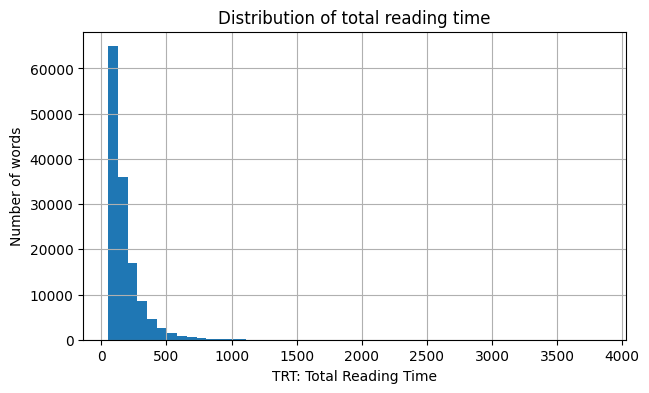

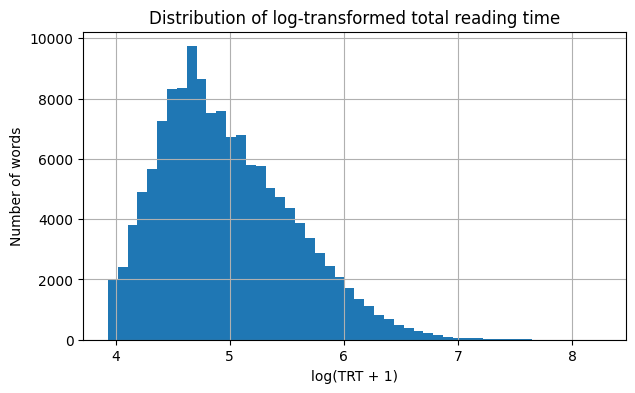

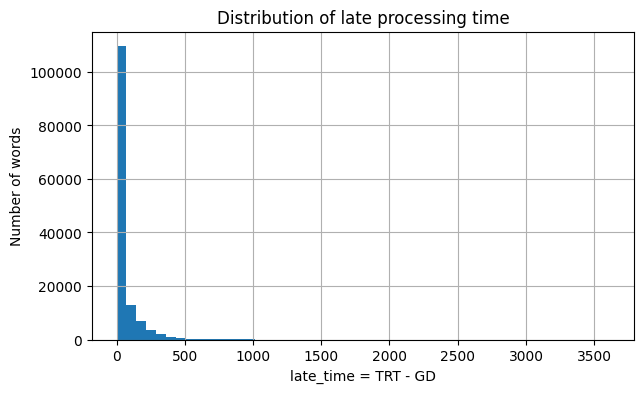

In [ ]:
plt.figure(figsize=(7, 4))
df_fixated["TRT"].dropna().hist(bins=50)
plt.xlabel("TRT: Total Reading Time")
plt.ylabel("Number of words")
plt.title("Distribution of total reading time")
plt.show()

plt.figure(figsize=(7, 4))
df_fixated["log_TRT"].dropna().hist(bins=50)
plt.xlabel("log(TRT + 1)")
plt.ylabel("Number of words")
plt.title("Distribution of log-transformed total reading time")
plt.show()

plt.figure(figsize=(7, 4))
df_fixated["late_time"].dropna().hist(bins=50)
plt.xlabel("late_time = TRT - GD")
plt.ylabel("Number of words")
plt.title("Distribution of late processing time")
plt.show()

<Figure size 700x400 with 0 Axes>

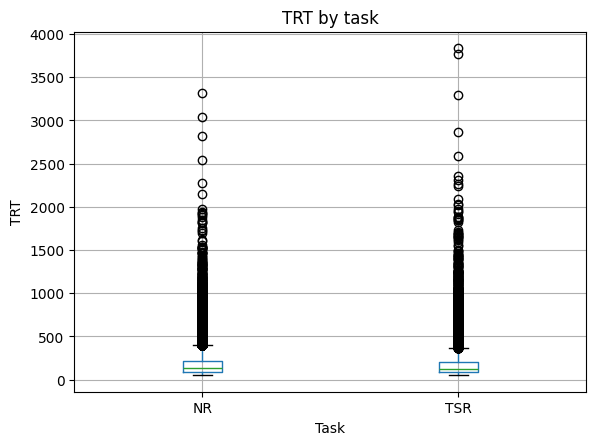

<Figure size 700x400 with 0 Axes>

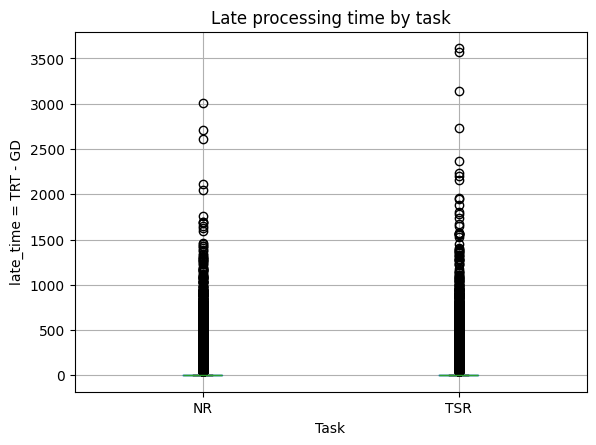

In [ ]:
if df["task"].nunique() >= 2:
    plt.figure(figsize=(7, 4))
    df_fixated.boxplot(column="TRT", by="task")
    plt.suptitle("")
    plt.title("TRT by task")
    plt.xlabel("Task")
    plt.ylabel("TRT")
    plt.show()

    plt.figure(figsize=(7, 4))
    df_fixated.boxplot(column="late_time", by="task")
    plt.suptitle("")
    plt.title("Late processing time by task")
    plt.xlabel("Task")
    plt.ylabel("late_time = TRT - GD")
    plt.show()
else:
    print("Only one task is available, so task comparison plots are skipped.")

# 11. Build modelling targets

## Target A: skipped

```text
target_skipped = 1 if word is skipped
```

## Target B: high late load

```text
late_time = TRT - GD
target_high_late_load = 1 if late_time is in top 25% within subject-task group
```

This is the main theoretical target.

## Target C: task classification

```text
target_task_TSR = 1 for TSR, 0 for NR
```

Only available if both NR and TSR are loaded.

In [ ]:
def add_rank_based_binary_target(
    df,
    value_col,
    target_col,
    valid_mask,
    group_cols=("subject_id", "task"),
    top_quantile=0.75,
    min_group_n=20
):
    """
    Create a rank-based high-load target within groups.

    Why rank-based?
    If many late_time values are zero or tied, direct quantile thresholds can label
    too many or too few observations. Percentile ranks handle ties more gracefully.

    target = 1 means the observation is in the top tail of the group's distribution.
    """
    df[target_col] = np.nan
    df[f"{target_col}_percentile"] = np.nan

    grouped = df.loc[valid_mask].groupby(list(group_cols), dropna=False)

    for group_key, group in grouped:
        idx = group.index
        values = group[value_col].dropna()

        if len(values) < min_group_n or values.nunique() < 2:
            # Not enough variation for a meaningful binary target.
            continue

        ranks = group[value_col].rank(method="average", pct=True)
        df.loc[idx, f"{target_col}_percentile"] = ranks
        df.loc[idx, target_col] = (ranks >= top_quantile).astype(int)

    return df


def add_modelling_targets(df, top_quantile=0.75, min_group_n=20):
    """
    Add ML targets for skipping, high late load, high total load, and task.

    The main target is target_high_late_load:
        late_time = TRT - GD
        high = top 25% within subject-task group by percentile rank
    """
    df = df.copy()

    # Target A: skipping.
    df["target_skipped"] = df["skipped"].astype(int)

    # Target B: high late processing load.
    valid_late = (
        (df["is_fixated"] == 1)
        & df["late_time"].notna()
        & np.isfinite(df["late_time"])
    )

    df = add_rank_based_binary_target(
        df=df,
        value_col="late_time",
        target_col="target_high_late_load",
        valid_mask=valid_late,
        group_cols=("subject_id", "task"),
        top_quantile=top_quantile,
        min_group_n=min_group_n
    )

    # Comparison target: high total reading time.
    valid_trt = (
        (df["is_fixated"] == 1)
        & df["TRT"].notna()
        & np.isfinite(df["TRT"])
    )

    df = add_rank_based_binary_target(
        df=df,
        value_col="TRT",
        target_col="target_high_total_load",
        valid_mask=valid_trt,
        group_cols=("subject_id", "task"),
        top_quantile=top_quantile,
        min_group_n=min_group_n
    )

    # Optional task target.
    if set(df["task"].dropna().unique()).issuperset({"NR", "TSR"}):
        df["target_task_TSR"] = (df["task"] == "TSR").astype(int)
    else:
        df["target_task_TSR"] = np.nan

    return df


df_model = add_modelling_targets(df, top_quantile=0.75, min_group_n=20)

for target in ["target_skipped", "target_high_late_load", "target_high_total_load", "target_task_TSR"]:
    print("\n", target)
    display(df_model[target].value_counts(dropna=False, normalize=True).rename("proportion"))

print("\nTarget counts by subject-task:")
target_count_cols = ["target_high_late_load", "target_high_total_load"]
display(
    df_model
    .groupby(["subject_id", "task"])[target_count_cols]
    .agg(lambda s: s.value_counts(dropna=False).to_dict())
    .reset_index()
)


 target_skipped


,proportion
target_skipped,
0,0.59733
1,0.40267



 target_high_late_load


,proportion
target_high_late_load,
0.0,0.480009
NaN,0.402670
1.0,0.117321



 target_high_total_load


,proportion
target_high_total_load,
0.0,0.447739
NaN,0.402670
1.0,0.149591



 target_task_TSR


,proportion
target_task_TSR,
1,0.543997
0,0.456003



Target counts by subject-task:


,subject_id,task,target_high_late_load,target_high_total_load
0,YAC,NR,"{0.0: 2777, nan: 1659, 1.0: 497}","{0.0: 2459, nan: 1659, 1.0: 815}"
1,YAC,TSR,"{0.0: 3133, nan: 2114, 1.0: 379}","{0.0: 2630, nan: 2114, 1.0: 882}"
2,YAG,NR,"{0.0: 3903, nan: 1601, 1.0: 1306}","{0.0: 3905, nan: 1601, 1.0: 1304}"
3,YAG,TSR,"{0.0: 4472, nan: 2277, 1.0: 1495}","{0.0: 4476, nan: 2277, 1.0: 1491}"
4,YAK,NR,"{0.0: 3328, nan: 3293, 1.0: 189}","{nan: 3293, 0.0: 2637, 1.0: 880}"
5,YAK,TSR,"{0.0: 4919, nan: 2882, 1.0: 443}","{0.0: 4021, nan: 2882, 1.0: 1341}"
6,YDG,NR,"{0.0: 3209, nan: 2531, 1.0: 1070}","{0.0: 3206, nan: 2531, 1.0: 1073}"
7,YDG,TSR,"{nan: 4151, 0.0: 3395, 1.0: 698}","{nan: 4151, 0.0: 3068, 1.0: 1025}"
8,YDR,NR,"{nan: 3144, 0.0: 2749, 1.0: 917}","{nan: 3144, 0.0: 2747, 1.0: 919}"
9,YDR,TSR,"{nan: 5755, 0.0: 1998, 1.0: 491}","{nan: 5755, 0.0: 1863, 1.0: 626}"


# 12. Define feature families for one aligned B-series question

A scientific ML study should compare feature families in a way that answers one consistent question.

## Unified Model B question

> **Does first fixation duration, FFD, add robust predictive information about later processing load beyond lexical/contextual features?**

## Statistical principle

A fair model comparison changes **one information source at a time**:

```text
B1 = no eye-tracking duration
B2 = add FFD-based early fixation information
B3 = allow FFD effects to depend on context
B4 = allow nonlinear FFD-based decision boundaries
```

## B-series feature logic

### B1 — lexical/contextual baseline

These features do not use eye-tracking duration:

```text
word_length
log_word_length
sentence_length_words
word_position_norm
word-shape indicators
task, if enabled
```

### B2 — additive early-fixation model

Adds the FFD signal:

```text
FFD
log_FFD
```

`log_FFD` is not a new theoretical construct. It is a scale-stabilised version of FFD.

### B3 — moderated early-fixation model

Adds interaction features such as:

```text
log_FFD × log_word_length
log_FFD × word_position
log_FFD × is_long_word
```

Statistical interpretation:

> B3 tests whether the FFD effect is conditional on word/context properties.

### B4 — nonlinear early-fixation model

Uses a random forest with the same allowed early-signal feature family:

```text
lexical/contextual features + FFD + log_FFD
```

Statistical interpretation:

> B4 tests whether the FFD signal is robust under nonlinear classification.

---

## Why B3/B4 still do not use `GD` or `SFD`

The target is:

```text
late_time = TRT - GD
```

So `GD` is mathematically involved in the target definition.  
`SFD` is behaviourally special because it only exists for single-fixation words.

To keep every B model answering the same question, B3/B4 focus on the **same early signal family** centred on `FFD`.

In [ ]:
def existing_features(df, features):
    return [f for f in features if f in df.columns]


# ---------------------------------------------------------------------
# B-series alignment principle
# ---------------------------------------------------------------------
# B1-B4 should answer the same question:
# "Does early fixation information, especially FFD, improve prediction of late processing load?"
#
# Therefore, the central B-series feature sets deliberately avoid:
# GD, SFD, TRT, GPT, nFixations, late_time
# for target_high_late_load.
# ---------------------------------------------------------------------


# Safe FFD transformation.
# Statistical reason:
# FFD is often right-skewed. log_FFD improves numerical stability while preserving
# the same underlying early-fixation signal.
if "FFD" in df_model.columns:
    df_model["log_FFD"] = np.log1p(pd.to_numeric(df_model["FFD"], errors="coerce"))
else:
    df_model["log_FFD"] = np.nan


# A richer lexical baseline makes the scientific comparison more conservative.
LEXICAL_NUMERIC = existing_features(df_model, [
    "word_length",
    "log_word_length",
    "sentence_length_words",
    "word_position_norm",
    "is_stopword",
    "is_numeric",
    "has_digit",
    "is_capitalized",
    "is_all_caps",
    "is_short_word",
    "is_long_word",
    "is_sentence_initial",
    "is_sentence_final"
])

LEXICAL_CATEGORICAL = existing_features(df_model, ["task"]) if USE_TASK_AS_FEATURE else []


# Create a numeric task flag only for possible interaction construction.
if "task" in df_model.columns:
    df_model["task_is_TSR"] = (df_model["task"].astype(str).str.upper() == "TSR").astype(int)
else:
    df_model["task_is_TSR"] = 0


# B2: additive early-fixation model.
# FFD and log_FFD are both FFD-based. The research question remains the same.
EARLY_EYE_NUMERIC = existing_features(df_model, LEXICAL_NUMERIC + [
    "FFD",
    "log_FFD"
])


# B3: moderated FFD model.
# These interaction terms keep B3 on the same question: FFD signal under context moderation.
if "log_FFD" in df_model.columns:
    if "log_word_length" in df_model.columns:
        df_model["log_FFD_x_log_word_length"] = df_model["log_FFD"] * df_model["log_word_length"]
    if "word_position_norm" in df_model.columns:
        df_model["log_FFD_x_word_position_norm"] = df_model["log_FFD"] * df_model["word_position_norm"]
    if "is_long_word" in df_model.columns:
        df_model["log_FFD_x_is_long_word"] = df_model["log_FFD"] * df_model["is_long_word"]
    if "is_sentence_final" in df_model.columns:
        df_model["log_FFD_x_is_sentence_final"] = df_model["log_FFD"] * df_model["is_sentence_final"]
    if USE_TASK_AS_FEATURE and "task_is_TSR" in df_model.columns:
        df_model["log_FFD_x_task_is_TSR"] = df_model["log_FFD"] * df_model["task_is_TSR"]

FFD_CONTEXT_INTERACTION_FEATURES = existing_features(df_model, [
    "log_FFD_x_log_word_length",
    "log_FFD_x_word_position_norm",
    "log_FFD_x_is_long_word",
    "log_FFD_x_is_sentence_final",
    "log_FFD_x_task_is_TSR"
])

CONFIRMATORY_FFD_INTERACTION_NUMERIC = existing_features(
    df_model,
    EARLY_EYE_NUMERIC + FFD_CONTEXT_INTERACTION_FEATURES
)

# B4: nonlinear robustness model using the same allowed early-signal family.
CONFIRMATORY_FFD_NONLINEAR_NUMERIC = EARLY_EYE_NUMERIC.copy()

# Backward-compatible alias, but no longer "first-pass exploratory".
FIRST_PASS_EYE_NUMERIC = CONFIRMATORY_FFD_INTERACTION_NUMERIC.copy()


TASK_CLASSIFICATION_NUMERIC = existing_features(df_model, [
    "word_length",
    "log_word_length",
    "sentence_length_words",
    "word_position_norm",
    "is_stopword",
    "is_numeric",
    "is_capitalized",
    "is_short_word",
    "skipped",
    "FFD",
    "log_FFD",
    "GD",
    "TRT",
    "GPT",
    "SFD",
    "nFixations",
    "late_time"
])

TASK_CLASSIFICATION_CATEGORICAL = []


# Target-leakage guardrails.
FORBIDDEN_FEATURES_BY_TARGET = {
    "target_skipped": set(),
    "target_high_late_load": {
        "late_time", "log_late_time",
        "TRT", "log_TRT",
        "GPT", "log_GPT",
        "GD", "log_GD",
        "SFD", "log_SFD",
        "nFixations"
    },
    "target_high_total_load": {
        "TRT", "log_TRT",
        "GPT", "log_GPT",
        "GD", "log_GD",
        "SFD", "log_SFD",
        "nFixations",
        "late_time", "log_late_time"
    },
    "target_task_TSR": set()
}


def assert_no_target_leakage(target_col, features):
    """
    Block known forbidden predictors for a modelling target.

    Statistical reason:
    If a predictor is mathematically or behaviourally too close to the target,
    high accuracy can be inflated and scientifically misleading.
    """
    forbidden = FORBIDDEN_FEATURES_BY_TARGET.get(target_col, set())

    leaked = []
    for feature in features:
        for bad in forbidden:
            if (
                feature == bad
                or feature.startswith(f"{bad}_x_")
                or feature.endswith(f"_x_{bad}")
                or feature.startswith(f"log_{bad}_x_")
            ):
                leaked.append(feature)

    leaked = sorted(set(leaked))
    if leaked:
        raise ValueError(
            f"Target leakage risk for {target_col}. Remove forbidden predictors: {leaked}"
        )


print("LEXICAL_NUMERIC:", LEXICAL_NUMERIC)
print("LEXICAL_CATEGORICAL:", LEXICAL_CATEGORICAL)
print("EARLY_EYE_NUMERIC / B2 features:", EARLY_EYE_NUMERIC)
print("FFD_CONTEXT_INTERACTION_FEATURES:", FFD_CONTEXT_INTERACTION_FEATURES)
print("CONFIRMATORY_FFD_INTERACTION_NUMERIC / B3 features:", CONFIRMATORY_FFD_INTERACTION_NUMERIC)
print("CONFIRMATORY_FFD_NONLINEAR_NUMERIC / B4 features:", CONFIRMATORY_FFD_NONLINEAR_NUMERIC)
print("TASK_CLASSIFICATION_NUMERIC:", TASK_CLASSIFICATION_NUMERIC)

# Sanity checks: these should pass.
assert_no_target_leakage("target_high_late_load", LEXICAL_NUMERIC + LEXICAL_CATEGORICAL)
assert_no_target_leakage("target_high_late_load", EARLY_EYE_NUMERIC + LEXICAL_CATEGORICAL)
assert_no_target_leakage("target_high_late_load", CONFIRMATORY_FFD_INTERACTION_NUMERIC + LEXICAL_CATEGORICAL)
assert_no_target_leakage("target_high_late_load", CONFIRMATORY_FFD_NONLINEAR_NUMERIC + LEXICAL_CATEGORICAL)

LEXICAL_NUMERIC: ['word_length', 'log_word_length', 'sentence_length_words', 'word_position_norm', 'is_stopword', 'is_numeric', 'has_digit', 'is_capitalized', 'is_all_caps', 'is_short_word', 'is_long_word', 'is_sentence_initial', 'is_sentence_final']
LEXICAL_CATEGORICAL: ['task']
EARLY_EYE_NUMERIC / B2 features: ['word_length', 'log_word_length', 'sentence_length_words', 'word_position_norm', 'is_stopword', 'is_numeric', 'has_digit', 'is_capitalized', 'is_all_caps', 'is_short_word', 'is_long_word', 'is_sentence_initial', 'is_sentence_final', 'FFD', 'log_FFD']
FFD_CONTEXT_INTERACTION_FEATURES: ['log_FFD_x_log_word_length', 'log_FFD_x_word_position_norm', 'log_FFD_x_is_long_word', 'log_FFD_x_is_sentence_final', 'log_FFD_x_task_is_TSR']
CONFIRMATORY_FFD_INTERACTION_NUMERIC / B3 features: ['word_length', 'log_word_length', 'sentence_length_words', 'word_position_norm', 'is_stopword', 'is_numeric', 'has_digit', 'is_capitalized', 'is_all_caps', 'is_short_word', 'is_long_word', 'is_sentence_i

# 13. Modelling functions with validation-only accuracy optimisation

These functions build and evaluate models.

## Why grouped train/test split?

Words in the same sentence are correlated.  
So we split by `sentence_hash` or `sentence_uid` to avoid putting related words into both training and test sets.

## Why validation tuning?

A model can look better if we tune threshold or hyperparameters on the test set.  
That is invalid because the test set would no longer be independent.

This notebook uses:

```text
training split   -> fit model
validation split -> choose hyperparameters and threshold
test split       -> final evaluation
```

## Main statistical metrics

| Metric | Meaning |
|---|---|
| Accuracy | Overall proportion correct; can be misleading with imbalance |
| Balanced accuracy | Mean of sensitivity and specificity; better for imbalanced targets |
| Precision | Among predicted positives, proportion truly positive |
| Recall | Among true positives, proportion detected |
| F1 | Harmonic mean of precision and recall |
| ROC-AUC | Ranking quality across all thresholds |
| Average precision | Precision-recall performance; useful with class imbalance |
| Brier score | Calibration error for probabilities; lower is better |

In [ ]:
# Defaults for older notebooks or partial execution.
TUNE_MODEL_HYPERPARAMETERS = globals().get("TUNE_MODEL_HYPERPARAMETERS", True)
TUNE_CLASSIFICATION_THRESHOLD = globals().get("TUNE_CLASSIFICATION_THRESHOLD", True)
THRESHOLD_OPTIMIZATION_METRIC = globals().get("THRESHOLD_OPTIMIZATION_METRIC", "balanced_accuracy")
VALIDATION_SIZE = globals().get("VALIDATION_SIZE", 0.20)
TUNING_MAX_CANDIDATES = globals().get("TUNING_MAX_CANDIDATES", 12)


def make_onehot_encoder():
    """
    Compatible OneHotEncoder for different sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(numeric_features, categorical_features):
    """
    Build preprocessing pipelines.

    Numeric predictors:
    - median imputation
    - standardisation

    Categorical predictors:
    - most-frequent imputation
    - one-hot encoding

    Statistical annotation:
    Imputation is applied inside the training pipeline, so the test set does not influence
    the imputation values.
    """
    transformers = []

    if numeric_features:
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", numeric_pipeline, numeric_features))

    if categorical_features:
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ])
        transformers.append(("cat", categorical_pipeline, categorical_features))

    if not transformers:
        raise ValueError("At least one numeric or categorical feature is required.")

    return ColumnTransformer(transformers=transformers, remainder="drop")


def make_classifier_pipeline(numeric_features, categorical_features, model_type="logreg"):
    """
    Build preprocessing + classifier pipeline.
    """
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    if model_type == "dummy":
        classifier = DummyClassifier(strategy="most_frequent")

    elif model_type == "logreg":
        classifier = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        )

    elif model_type == "rf":
        classifier = RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            min_samples_leaf=5,
            n_jobs=-1
        )

    else:
        raise ValueError("model_type must be 'dummy', 'logreg', or 'rf'.")

    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", classifier)
    ])


def candidate_parameter_grid(model_type):
    """
    Small validation-tuning grids.

    Statistical annotation:
    The grid is deliberately small to reduce overfitting to the validation set and keep
    Colab runtime manageable.
    """
    if (not TUNE_MODEL_HYPERPARAMETERS) or model_type == "dummy":
        return [{}]

    if model_type == "logreg":
        candidates = [
            {"classifier__C": C, "classifier__class_weight": cw}
            for C in [0.05, 0.10, 0.30, 1.0, 3.0, 10.0]
            for cw in ["balanced", None]
        ]

    elif model_type == "rf":
        candidates = [
            {
                "classifier__max_depth": max_depth,
                "classifier__min_samples_leaf": min_leaf,
                "classifier__max_features": max_features,
                "classifier__class_weight": cw
            }
            for max_depth in [4, 8, None]
            for min_leaf in [2, 5, 10]
            for max_features in ["sqrt", 0.60]
            for cw in ["balanced", "balanced_subsample"]
        ]

    else:
        candidates = [{}]

    # Reproducible candidate subsampling if the grid is large.
    if len(candidates) > TUNING_MAX_CANDIDATES:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(candidates), size=TUNING_MAX_CANDIDATES, replace=False)
        candidates = [candidates[i] for i in idx]

    return candidates


def is_trainable_binary_target(df, target_col, min_n=30):
    """
    Check whether a binary target has enough rows and both classes.
    """
    data = df.dropna(subset=[target_col]).copy()
    if len(data) < min_n:
        return False, f"not enough labelled rows: {len(data)} < {min_n}"
    if data[target_col].nunique() < 2:
        return False, f"fewer than two classes: {data[target_col].nunique()}"
    return True, "ok"


def choose_group_train_test_split(
    df,
    target_col,
    group_col=None,
    test_size=0.25,
    random_state=None,
    n_tries=100,
    max_rate_diff=0.20,
    verbose=True
):
    """
    Search for a grouped train/test split with both classes and acceptable class balance.

    Statistical annotation:
    GroupShuffleSplit is not stratified. With imbalanced targets, a single random split
    can produce a misleading test set. This function tries multiple seeds and chooses a
    split with closer train/test positive rates.
    """
    if group_col is None:
        group_col = GROUP_COL_FOR_VALIDATION
    if random_state is None:
        random_state = RANDOM_STATE

    data = df.dropna(subset=[target_col]).copy()
    data = data[data[group_col].notna()].copy()

    if data[target_col].nunique() < 2:
        raise ValueError(f"Target {target_col} has fewer than two classes.")
    if data[group_col].nunique() < 2:
        raise ValueError(f"Not enough groups in {group_col} for train/test splitting.")

    best = None
    best_score = np.inf

    for offset in range(n_tries):
        seed = random_state + offset
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        groups = data[group_col]
        train_idx, test_idx = next(splitter.split(data, data[target_col], groups))

        train_df = data.iloc[train_idx].copy()
        test_df = data.iloc[test_idx].copy()

        if train_df[target_col].nunique() < 2 or test_df[target_col].nunique() < 2:
            continue

        train_rate = train_df[target_col].astype(int).mean()
        test_rate = test_df[target_col].astype(int).mean()
        rate_diff = abs(train_rate - test_rate)

        score = rate_diff + 1 / max(test_df[group_col].nunique(), 1)

        if score < best_score:
            best_score = score
            best = (train_df, test_df, seed, train_rate, test_rate, rate_diff)

        if rate_diff <= max_rate_diff:
            break

    if best is None:
        raise ValueError(
            f"Could not find a valid grouped split for {target_col}. "
            "Try more data, a different group column, or a different RANDOM_STATE."
        )

    train_df, test_df, chosen_seed, train_rate, test_rate, rate_diff = best

    if verbose:
        print(
            f"Grouped split for {target_col}: seed={chosen_seed}, "
            f"train positive rate={train_rate:.3f}, test positive rate={test_rate:.3f}, "
            f"absolute difference={rate_diff:.3f}"
        )

    return train_df, test_df


def metric_value(y_true, y_pred, y_score=None, metric_name="balanced_accuracy"):
    """
    Compute a single validation-selection metric.
    """
    if metric_name == "balanced_accuracy":
        return balanced_accuracy_score(y_true, y_pred)
    if metric_name == "f1":
        return f1_score(y_true, y_pred, zero_division=0)
    if metric_name == "recall":
        return recall_score(y_true, y_pred, zero_division=0)
    if metric_name == "precision":
        return precision_score(y_true, y_pred, zero_division=0)
    if metric_name == "roc_auc" and y_score is not None and len(np.unique(y_true)) == 2:
        return roc_auc_score(y_true, y_score)
    raise ValueError(f"Unsupported metric for threshold optimisation: {metric_name}")


def tune_threshold(y_true, y_score, metric_name="balanced_accuracy", thresholds=None):
    """
    Choose a probability threshold on validation data only.

    Statistical annotation:
    This improves classification accuracy/F1 without contaminating the independent test set.
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    rows = []
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        rows.append({
            "threshold": float(threshold),
            "score": metric_value(y_true, y_pred, y_score, metric_name),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0)
        })

    out = pd.DataFrame(rows)
    best = out.sort_values(["score", "balanced_accuracy", "f1"], ascending=False).iloc[0]
    return float(best["threshold"]), float(best["score"]), out


def safe_binary_metrics(y_true, y_pred, y_score=None):
    """
    Compute binary classification metrics robustly.
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            metrics["roc_auc"] = np.nan

        try:
            metrics["average_precision"] = average_precision_score(y_true, y_score)
        except Exception:
            metrics["average_precision"] = np.nan

        try:
            metrics["brier_score"] = brier_score_loss(y_true, y_score)
        except Exception:
            metrics["brier_score"] = np.nan

    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan
        metrics["brier_score"] = np.nan

    return metrics


def predict_with_threshold(model, X, threshold=0.50):
    """
    Predict class labels using a tuned probability threshold when possible.
    """
    if hasattr(model.named_steps["classifier"], "predict_proba"):
        try:
            y_score = model.predict_proba(X)[:, 1]
            y_pred = (y_score >= threshold).astype(int)
            return y_pred, y_score
        except Exception:
            pass

    y_pred = model.predict(X)
    return y_pred, None


def fit_model_with_validation_tuning(
    train_valid_df,
    target_col,
    numeric_features,
    categorical_features,
    model_type,
    group_col=None,
    validation_size=None,
    random_state=None
):
    """
    Fit model using inner validation for hyperparameter and threshold selection.

    Workflow:
    1. Split train_valid into train and validation groups.
    2. Fit candidate models on train.
    3. Select hyperparameters and threshold on validation.
    4. Refit selected model on all train_valid rows.
    """
    if group_col is None:
        group_col = GROUP_COL_FOR_VALIDATION
    if validation_size is None:
        validation_size = VALIDATION_SIZE
    if random_state is None:
        random_state = RANDOM_STATE

    features = numeric_features + categorical_features
    assert_no_target_leakage(target_col, features)

    # Try to create a validation split. If not possible, fall back to no tuning.
    try:
        train_df, valid_df = choose_group_train_test_split(
            train_valid_df,
            target_col=target_col,
            group_col=group_col,
            test_size=validation_size,
            random_state=random_state + 1000,
            n_tries=50,
            max_rate_diff=0.25,
            verbose=False
        )
        use_validation = True
    except Exception as e:
        print("Validation split unavailable; using default parameters/threshold.")
        print("Reason:", e)
        train_df = train_valid_df.copy()
        valid_df = None
        use_validation = False

    X_train = train_df[features]
    y_train = train_df[target_col].astype(int)

    if use_validation:
        X_valid = valid_df[features]
        y_valid = valid_df[target_col].astype(int)
    else:
        X_valid = None
        y_valid = None

    candidate_params = candidate_parameter_grid(model_type)

    best = {
        "score": -np.inf,
        "params": {},
        "threshold": 0.50,
        "validation_score": np.nan,
        "validation_threshold_table": pd.DataFrame()
    }

    for params in candidate_params:
        candidate = make_classifier_pipeline(
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            model_type=model_type
        )
        if params:
            candidate.set_params(**params)

        candidate.fit(X_train, y_train)

        if use_validation:
            y_valid_pred_default, y_valid_score = predict_with_threshold(candidate, X_valid, threshold=0.50)

            if (
                TUNE_CLASSIFICATION_THRESHOLD
                and y_valid_score is not None
                and model_type != "dummy"
            ):
                threshold, score, threshold_table = tune_threshold(
                    y_true=y_valid,
                    y_score=y_valid_score,
                    metric_name=THRESHOLD_OPTIMIZATION_METRIC
                )
                y_valid_pred = (y_valid_score >= threshold).astype(int)
            else:
                threshold = 0.50
                threshold_table = pd.DataFrame()
                score = metric_value(
                    y_true=y_valid,
                    y_pred=y_valid_pred_default,
                    y_score=y_valid_score,
                    metric_name=THRESHOLD_OPTIMIZATION_METRIC
                )
                y_valid_pred = y_valid_pred_default

            # Tie-breakers favour simpler default threshold when performance is identical.
            if score > best["score"]:
                best = {
                    "score": float(score),
                    "params": params,
                    "threshold": float(threshold),
                    "validation_score": float(score),
                    "validation_threshold_table": threshold_table
                }
        else:
            # No validation split: use defaults.
            best = {
                "score": np.nan,
                "params": params,
                "threshold": 0.50,
                "validation_score": np.nan,
                "validation_threshold_table": pd.DataFrame()
            }
            break

    # Refit final model on all train_valid rows with selected hyperparameters.
    final_model = make_classifier_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type
    )

    if best["params"]:
        final_model.set_params(**best["params"])

    X_train_valid = train_valid_df[features]
    y_train_valid = train_valid_df[target_col].astype(int)

    final_model.fit(X_train_valid, y_train_valid)

    tuning_info = {
        "selected_params": best["params"],
        "decision_threshold": best["threshold"],
        "validation_score": best["validation_score"],
        "n_validation": int(len(valid_df)) if use_validation else 0,
        "hyperparameter_tuned": bool(TUNE_MODEL_HYPERPARAMETERS and model_type != "dummy"),
        "threshold_tuned": bool(TUNE_CLASSIFICATION_THRESHOLD and model_type != "dummy" and use_validation),
        "threshold_optimization_metric": THRESHOLD_OPTIMIZATION_METRIC,
        "validation_threshold_table": best["validation_threshold_table"]
    }

    return final_model, tuning_info


def fit_and_evaluate_model(
    df,
    target_col,
    numeric_features,
    categorical_features,
    model_type="logreg",
    model_name="model",
    group_col=None,
    test_size=0.25,
    random_state=None,
    show_plots=True
):
    """
    Fit and evaluate a binary classifier with grouped train/test split and validation-only tuning.

    Statistical annotation:
    The reported test metrics are computed on held-out groups that are not used for either
    fitting or tuning. This keeps the final evaluation more honest.
    """
    if group_col is None:
        group_col = GROUP_COL_FOR_VALIDATION
    if random_state is None:
        random_state = RANDOM_STATE

    trainable, reason = is_trainable_binary_target(df, target_col)
    if not trainable:
        print(f"Model skipped for {target_col}: {reason}")
        return None, None, None

    features = numeric_features + categorical_features
    assert_no_target_leakage(target_col, features)

    train_valid_df, test_df = choose_group_train_test_split(
        df=df,
        target_col=target_col,
        group_col=group_col,
        test_size=test_size,
        random_state=random_state
    )

    model, tuning_info = fit_model_with_validation_tuning(
        train_valid_df=train_valid_df,
        target_col=target_col,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type,
        group_col=group_col,
        validation_size=VALIDATION_SIZE,
        random_state=random_state
    )

    X_test = test_df[features]
    y_test = test_df[target_col].astype(int)

    y_pred, y_score = predict_with_threshold(
        model,
        X_test,
        threshold=tuning_info["decision_threshold"]
    )

    metrics = safe_binary_metrics(y_test, y_pred, y_score)
    metrics["model"] = model_name
    metrics["target"] = target_col
    metrics["model_type"] = model_type
    metrics["group_col"] = group_col
    metrics["n_train"] = len(train_valid_df)
    metrics["n_test"] = len(test_df)
    metrics["n_train_groups"] = train_valid_df[group_col].nunique()
    metrics["n_test_groups"] = test_df[group_col].nunique()
    metrics["positive_rate_train"] = train_valid_df[target_col].astype(int).mean()
    metrics["positive_rate_test"] = y_test.mean()
    metrics["decision_threshold"] = tuning_info["decision_threshold"]
    metrics["validation_score"] = tuning_info["validation_score"]
    metrics["n_validation"] = tuning_info["n_validation"]
    metrics["selected_params"] = str(tuning_info["selected_params"])
    metrics["hyperparameter_tuned"] = tuning_info["hyperparameter_tuned"]
    metrics["threshold_tuned"] = tuning_info["threshold_tuned"]
    metrics["threshold_optimization_metric"] = tuning_info["threshold_optimization_metric"]

    print(f"\n=== {model_name} ===")
    print("Statistical interpretation:")
    print("- Test metrics below are evaluated on held-out groups only.")
    print("- decision_threshold was selected on validation data, not test data.")
    print("- balanced_accuracy is prioritised because high-load labels are usually imbalanced.")
    display(pd.DataFrame([metrics]))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    if show_plots:
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm).plot()
        plt.title(f"Confusion matrix: {model_name}")
        plt.show()

        if y_score is not None and len(np.unique(y_test)) == 2:
            RocCurveDisplay.from_predictions(y_test, y_score)
            plt.title(f"ROC curve: {model_name}")
            plt.show()

            PrecisionRecallDisplay.from_predictions(y_test, y_score)
            plt.title(f"Precision-recall curve: {model_name}")
            plt.show()

    pred_df = test_df.copy()
    pred_df[f"pred_{target_col}"] = y_pred
    pred_df[f"threshold_{target_col}"] = tuning_info["decision_threshold"]

    if y_score is not None:
        pred_df[f"prob_{target_col}"] = y_score

    # Attach tuning diagnostics for optional later inspection.
    pred_df.attrs["tuning_info"] = tuning_info

    return model, metrics, pred_df

# 14. Model A — Predict word skipping

## Research question

> **Can lexical and positional features predict whether a word is skipped?**

Target:

```text
target_skipped
```

Predictors:

```text
word_length
sentence_length_words
word_position_norm
task
```

Target distribution:


,proportion
target_skipped,
0,0.59733
1,0.40267


Grouped split for target_skipped: seed=42, train positive rate=0.404, test positive rate=0.397, absolute difference=0.007

=== Model A0: skipped-word dummy baseline ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.60283,0.5,0.0,0.0,0.0,0.5,0.39717,0.39717,Model A0: skipped-word dummy baseline,target_skipped,dummy,sentence_hash,174776,55626,497,166,0.404421,0.39717,0.5,0.5,33340,{},False,False,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75     33533
           1       0.00      0.00      0.00     22093

    accuracy                           0.60     55626
   macro avg       0.30      0.50      0.38     55626
weighted avg       0.36      0.60      0.45     55626

Grouped split for target_skipped: seed=42, train positive rate=0.404, test positive rate=0.397, absolute difference=0.007

=== Model A1: skipped-word lexical logistic regression ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.682738,0.689149,0.581163,0.720319,0.643302,0.747034,0.637451,0.204591,Model A1: skipped-word lexical logistic regression,target_skipped,logreg,sentence_hash,174776,55626,497,166,0.404421,0.39717,0.475,0.69678,33340,"{'classifier__C': 0.05, 'classifier__class_weight': 'balanced'}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.71     33533
           1       0.58      0.72      0.64     22093

    accuracy                           0.68     55626
   macro avg       0.68      0.69      0.68     55626
weighted avg       0.70      0.68      0.69     55626



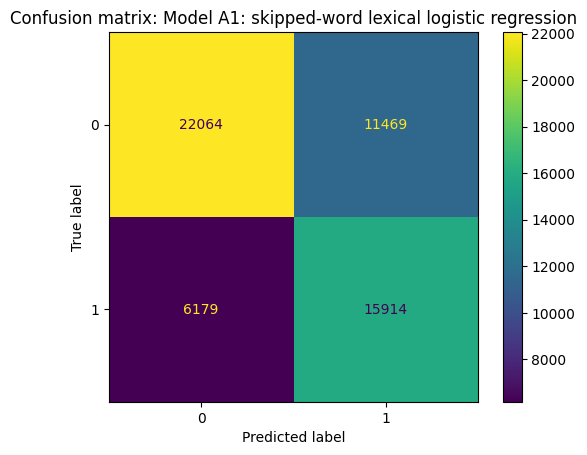

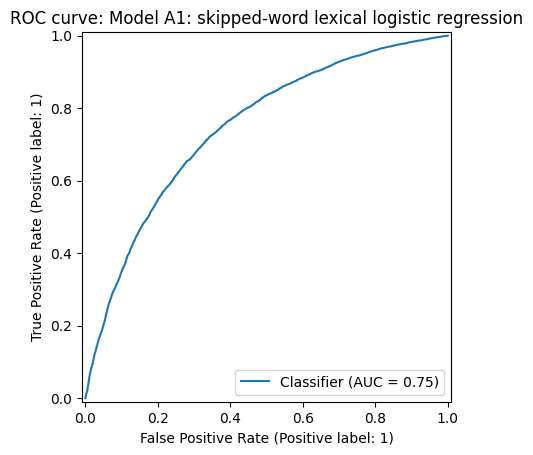

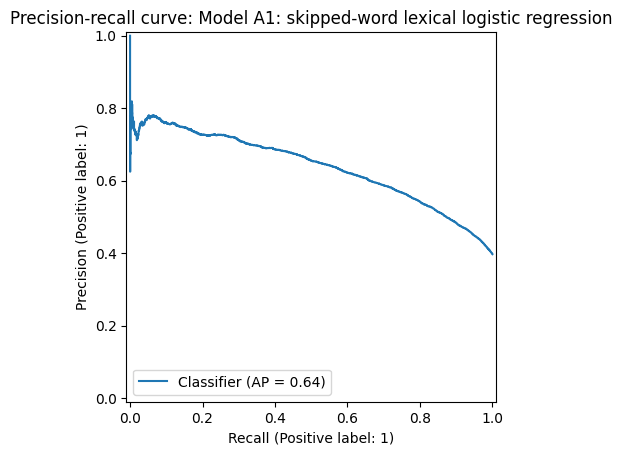

Grouped split for target_skipped: seed=42, train positive rate=0.404, test positive rate=0.397, absolute difference=0.007

=== Model A2: skipped-word lexical random forest ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.698181,0.691572,0.61127,0.65944,0.634442,0.754288,0.6524,0.202247,Model A2: skipped-word lexical random forest,target_skipped,rf,sentence_hash,174776,55626,497,166,0.404421,0.39717,0.525,0.694621,33340,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanc...",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74     33533
           1       0.61      0.66      0.63     22093

    accuracy                           0.70     55626
   macro avg       0.69      0.69      0.69     55626
weighted avg       0.70      0.70      0.70     55626



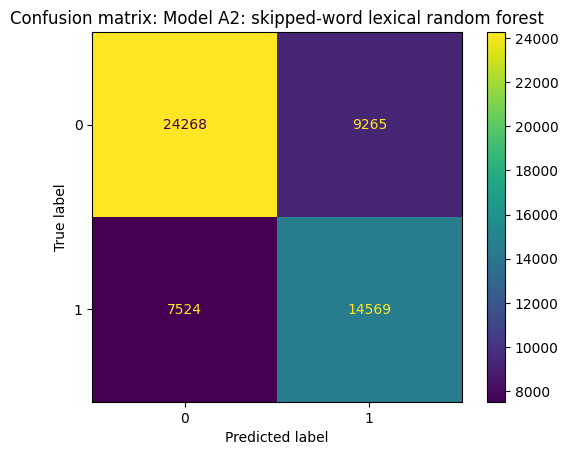

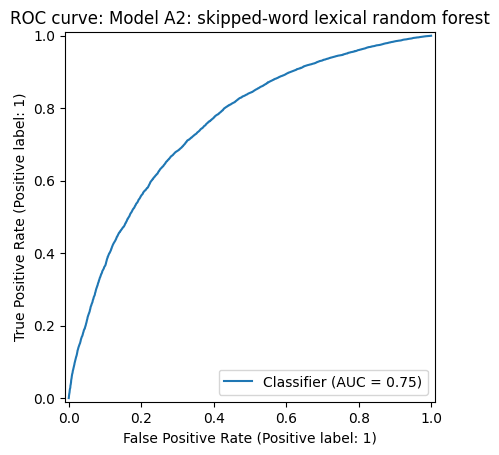

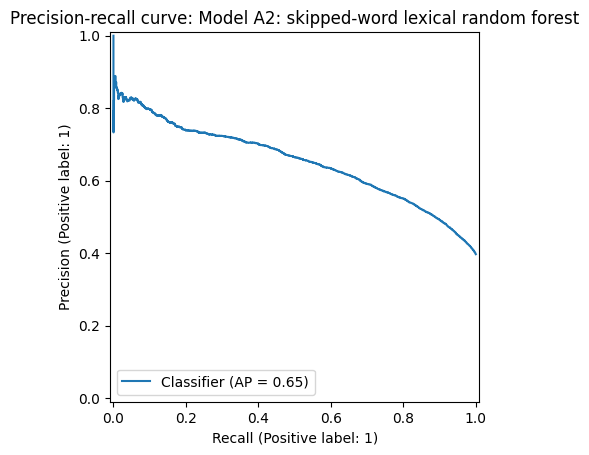

In [ ]:
skip_df = df_model.copy()

print("Target distribution:")
display(skip_df["target_skipped"].value_counts(normalize=True).rename("proportion"))

skip_dummy_model, skip_dummy_metrics, skip_dummy_pred = fit_and_evaluate_model(
    df=skip_df,
    target_col="target_skipped",
    numeric_features=LEXICAL_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="dummy",
    model_name="Model A0: skipped-word dummy baseline",
    show_plots=False
)

skip_logreg_model, skip_logreg_metrics, skip_logreg_pred = fit_and_evaluate_model(
    df=skip_df,
    target_col="target_skipped",
    numeric_features=LEXICAL_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="logreg",
    model_name="Model A1: skipped-word lexical logistic regression"
)

skip_rf_model, skip_rf_metrics, skip_rf_pred = fit_and_evaluate_model(
    df=skip_df,
    target_col="target_skipped",
    numeric_features=LEXICAL_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="rf",
    model_name="Model A2: skipped-word lexical random forest"
)

## Interpretation of Model A

If the lexical models beat the dummy model, skipping is not random.

Possible scientific interpretation:

> Word skipping is partly predictable from word length and word position, suggesting that visual attention allocation during reading is systematically related to lexical/contextual properties.

# 15. Model B — Main novelty model: predict high late processing load

## Research question

> **Can early fixation behaviour predict later word-level processing burden?**

Target:

```text
target_high_late_load
```

defined from:

```text
late_time = TRT - GD
```

This is more leakage-aware than predicting `TRT` directly.

In [ ]:
late_df = df_model[
    (df_model["is_fixated"] == 1)
    & df_model["target_high_late_load"].notna()
].copy()

late_df["target_high_late_load"] = late_df["target_high_late_load"].astype(int)

print("Late-load modelling rows:", late_df.shape)
display(late_df["target_high_late_load"].value_counts(normalize=True).rename("proportion"))

display(late_df[[
    "subject_id", "task", "sentence_id", "word",
    "word_length", "FFD", "GD", "TRT", "late_time",
    "target_high_late_load"
]].head(20))

Late-load modelling rows: (137626, 63)


,proportion
target_high_late_load,
0,0.803591
1,0.196409


,subject_id,task,sentence_id,word,word_length,FFD,GD,TRT,late_time,target_high_late_load
0,YAC,NR,0,Henry,5,51.0,51.0,51.0,0.0,0
1,YAC,NR,0,"Ford,",5,66.0,66.0,233.0,167.0,1
2,YAC,NR,0,with,4,66.0,66.0,66.0,0.0,0
4,YAC,NR,0,son,3,55.0,55.0,55.0,0.0,0
5,YAC,NR,0,"Edsel,",6,147.0,147.0,147.0,0.0,0
6,YAC,NR,0,founded,7,194.0,194.0,194.0,0.0,0
8,YAC,NR,0,Ford,4,189.0,189.0,189.0,0.0,0
9,YAC,NR,0,Foundation,10,69.0,69.0,69.0,0.0,0
10,YAC,NR,0,in,2,51.0,51.0,51.0,0.0,0
11,YAC,NR,0,1936,4,749.0,749.0,749.0,0.0,0


## 15.1 Model B0 — Dummy baseline

This model predicts the most common class.  
Every useful model should beat it.

In [ ]:
late_dummy_model, late_dummy_metrics, late_dummy_pred = fit_and_evaluate_model(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=LEXICAL_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="dummy",
    model_name="Model B0: high-late-load dummy baseline",
    show_plots=False
)

Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005

=== Model B0: high-late-load dummy baseline ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.799988,0.5,0.0,0.0,0.0,0.5,0.200012,0.200012,Model B0: high-late-load dummy baseline,target_high_late_load,dummy,sentence_hash,104093,33533,497,166,0.195248,0.200012,0.5,0.5,19671,{},False,False,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     26826
           1       0.00      0.00      0.00      6707

    accuracy                           0.80     33533
   macro avg       0.40      0.50      0.44     33533
weighted avg       0.64      0.80      0.71     33533



## 15.2 Model B1 — Lexical baseline

This model asks:

> How much late reading difficulty can be predicted without eye-tracking?

Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005

=== Model B1: high-late-load lexical baseline ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.5893,0.590282,0.264578,0.591919,0.365696,0.626353,0.294502,0.154747,Model B1: high-late-load lexical baseline,target_high_late_load,logreg,sentence_hash,104093,33533,497,166,0.195248,0.200012,0.2,0.59964,19671,"{'classifier__C': 0.05, 'classifier__class_weight': None}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.85      0.59      0.70     26826
           1       0.26      0.59      0.37      6707

    accuracy                           0.59     33533
   macro avg       0.56      0.59      0.53     33533
weighted avg       0.73      0.59      0.63     33533



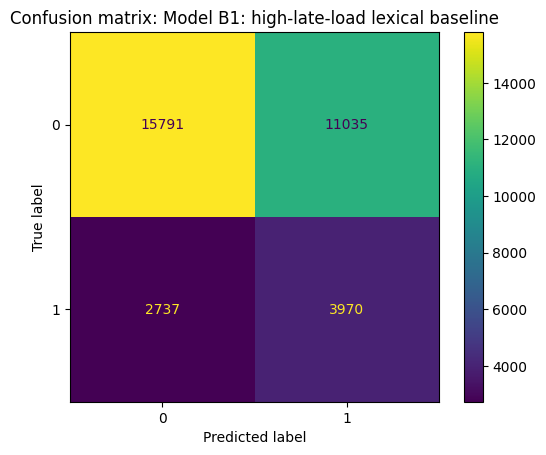

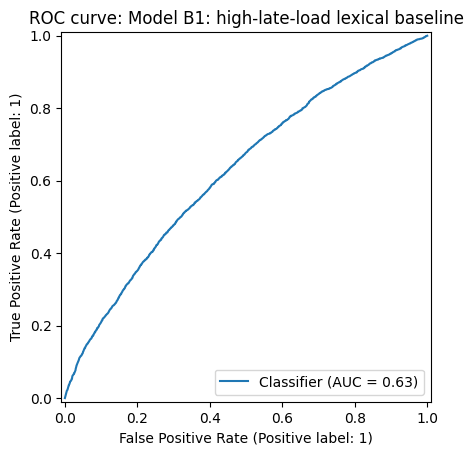

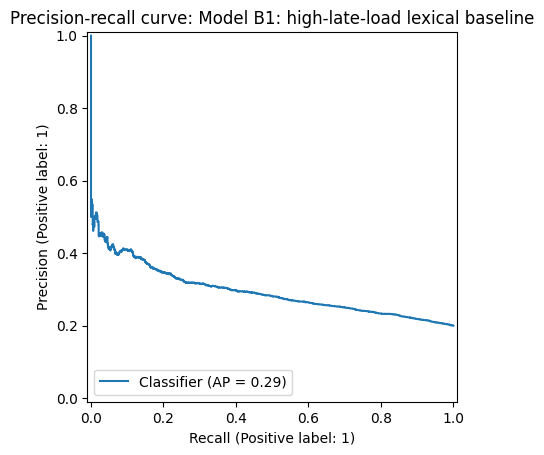

In [ ]:
late_lex_model, late_lex_metrics, late_lex_pred = fit_and_evaluate_model(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=LEXICAL_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="logreg",
    model_name="Model B1: high-late-load lexical baseline"
)

## 15.3 Model B2 — Additive FFD model

This model adds FFD-based early fixation information:

```text
FFD
log_FFD
```

Scientific test:

> Does first fixation duration improve prediction of later processing load beyond lexical/contextual features?

Statistical interpretation:

- If B2 improves over B1, the added FFD signal contains predictive information.
- If B2 does not improve over B1, FFD may not add linear/additive information in this sample.
- Hyperparameters and probability threshold are tuned on validation data only.

Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005

=== Model B2: high-late-load lexical + FFD model ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.625175,0.594422,0.277076,0.543164,0.36696,0.630216,0.296204,0.236952,Model B2: high-late-load lexical + FFD model,target_high_late_load,logreg,sentence_hash,104093,33533,497,166,0.195248,0.200012,0.525,0.601278,19671,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.85      0.65      0.73     26826
           1       0.28      0.54      0.37      6707

    accuracy                           0.63     33533
   macro avg       0.56      0.59      0.55     33533
weighted avg       0.74      0.63      0.66     33533



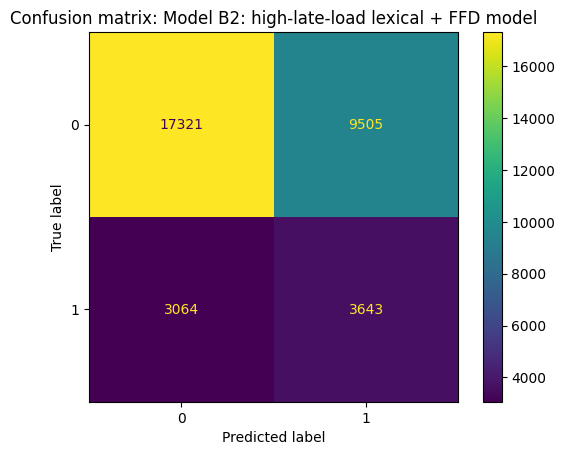

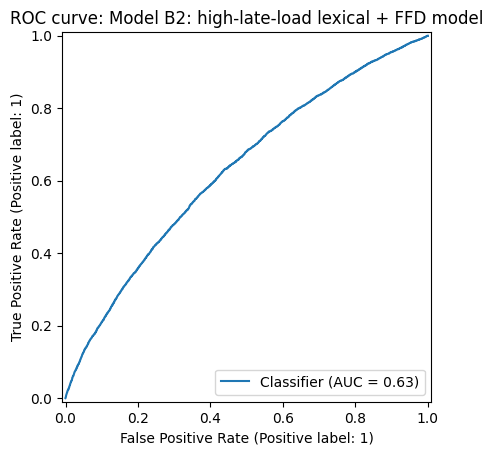

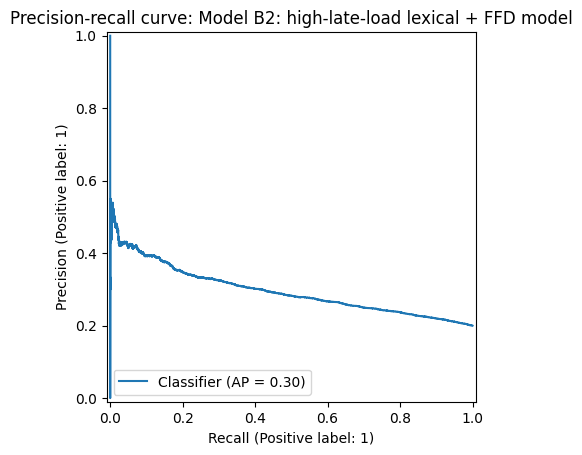

In [ ]:
late_early_model, late_early_metrics, late_early_pred = fit_and_evaluate_model(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=EARLY_EYE_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="logreg",
    model_name="Model B2: high-late-load lexical + FFD model"
)

## 15.3A Threshold and probability diagnostics for Model B2

The model now chooses its decision threshold on a validation split.

This section is diagnostic:

- It shows how the B2 test-set metrics would change across thresholds.
- It does **not** choose the final threshold from the test set.
- The actual test-set prediction uses the validation-selected threshold saved in `late_early_metrics`.

Statistical interpretation:

> If performance varies greatly across thresholds, probability calibration and class imbalance matter.

Validation-selected threshold used by Model B2: 0.525


,threshold,balanced_accuracy,precision,recall,f1
9,0.50,0.595090,0.265247,0.618607,0.371292
10,0.55,0.589243,0.289422,0.462204,0.355954
8,0.45,0.584387,0.244520,0.741762,0.367797
11,0.60,0.571953,0.324972,0.299389,0.311656
7,0.40,0.565521,0.228417,0.843000,0.359441
6,0.35,0.544941,0.216995,0.918742,0.351071
12,0.65,0.543348,0.377625,0.147458,0.212095
5,0.30,0.523188,0.208030,0.962576,0.342121
13,0.70,0.512542,0.429302,0.037573,0.069098
4,0.25,0.508108,0.202673,0.988072,0.336353


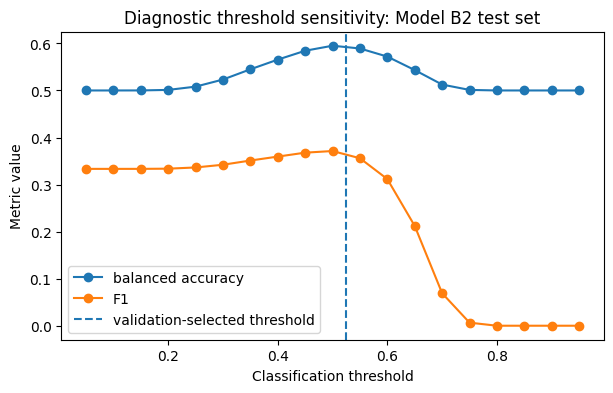

In [ ]:
def threshold_sensitivity_table(pred_df, target_col, prob_col, thresholds=None):
    """
    Evaluate classification metrics across probability thresholds.

    Statistical annotation:
    This is a diagnostic table for the held-out test set. It should not be used to choose
    the final threshold, because that would leak test information into the model decision rule.
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    if pred_df is None or prob_col not in pred_df.columns:
        return pd.DataFrame()

    y_true = pred_df[target_col].astype(int).values
    y_score = pred_df[prob_col].values

    rows = []
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)


if late_early_pred is None:
    print("Threshold analysis skipped because Model B2 was not fitted.")
else:
    prob_col = "prob_target_high_late_load"
    threshold_df = threshold_sensitivity_table(
        late_early_pred,
        target_col="target_high_late_load",
        prob_col=prob_col
    )

    chosen_threshold = None
    if isinstance(late_early_metrics, dict):
        chosen_threshold = late_early_metrics.get("decision_threshold", None)

    print("Validation-selected threshold used by Model B2:", chosen_threshold)

    if threshold_df.empty:
        print("Threshold analysis skipped because predicted probabilities are unavailable.")
    else:
        display(threshold_df.sort_values("balanced_accuracy", ascending=False).head(10))

        plt.figure(figsize=(7, 4))
        plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], marker="o", label="balanced accuracy")
        plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

        if chosen_threshold is not None:
            plt.axvline(chosen_threshold, linestyle="--", label="validation-selected threshold")

        plt.xlabel("Classification threshold")
        plt.ylabel("Metric value")
        plt.title("Diagnostic threshold sensitivity: Model B2 test set")
        plt.legend()
        plt.show()

## 15.4 Model B3 and B4 — Aligned robustness models with accuracy optimisation

B3 and B4 answer the **same research question** as B1 and B2:

> **Does FFD-based early fixation information improve prediction of high late processing load beyond lexical/contextual features?**

### Model B3 — moderated FFD logistic model

B3 adds interaction terms such as:

```text
log_FFD × log_word_length
log_FFD × word_position
log_FFD × is_long_word
```

Statistical interpretation:

> B3 tests whether the FFD effect is stronger or weaker depending on lexical/contextual properties.

### Model B4 — nonlinear FFD random forest

B4 uses a flexible nonlinear classifier with the same allowed early-signal feature family:

```text
lexical/contextual features + FFD + log_FFD
```

Statistical interpretation:

> B4 tests whether FFD-based information is useful when the decision boundary is nonlinear.

### Accuracy improvement in v4

Both models use validation-only tuning for hyperparameters and classification threshold.  
This can improve accuracy while keeping the test set independent.

Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005

=== Model B3: high-late-load moderated FFD logistic model ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.623028,0.595763,0.277185,0.550321,0.368676,0.632298,0.296765,0.236656,Model B3: high-late-load moderated FFD logistic model,target_high_late_load,logreg,sentence_hash,104093,33533,497,166,0.195248,0.200012,0.525,0.603272,19671,"{'classifier__C': 0.3, 'classifier__class_weight': 'balanced'}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     26826
           1       0.28      0.55      0.37      6707

    accuracy                           0.62     33533
   macro avg       0.56      0.60      0.55     33533
weighted avg       0.74      0.62      0.66     33533



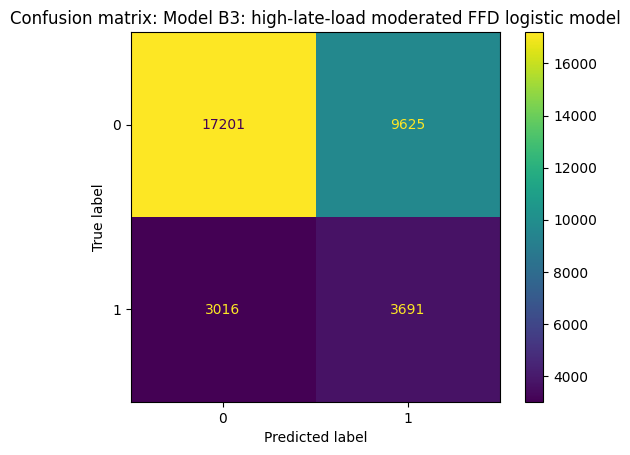

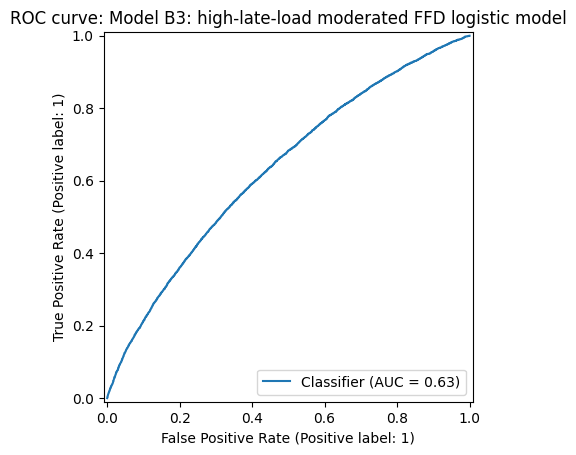

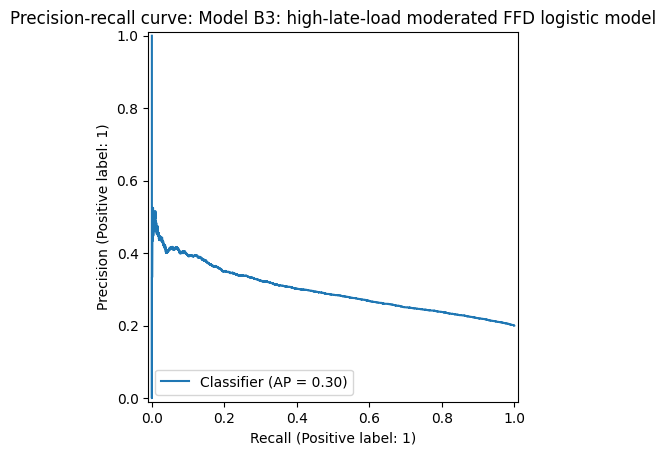

Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005

=== Model B4: high-late-load nonlinear FFD robustness model ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.627382,0.603349,0.283124,0.563292,0.376839,0.642929,0.304064,0.228784,Model B4: high-late-load nonlinear FFD robustness model,target_high_late_load,rf,sentence_hash,104093,33533,497,166,0.195248,0.200012,0.5,0.606854,19671,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.6, 'classifier__class_weight': 'balanced'}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     26826
           1       0.28      0.56      0.38      6707

    accuracy                           0.63     33533
   macro avg       0.57      0.60      0.56     33533
weighted avg       0.74      0.63      0.66     33533



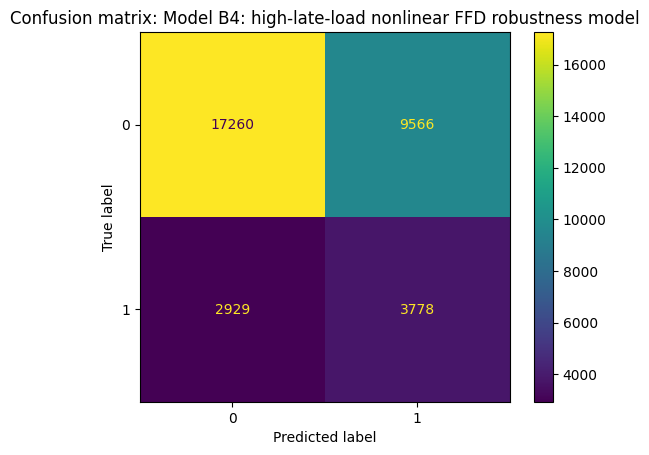

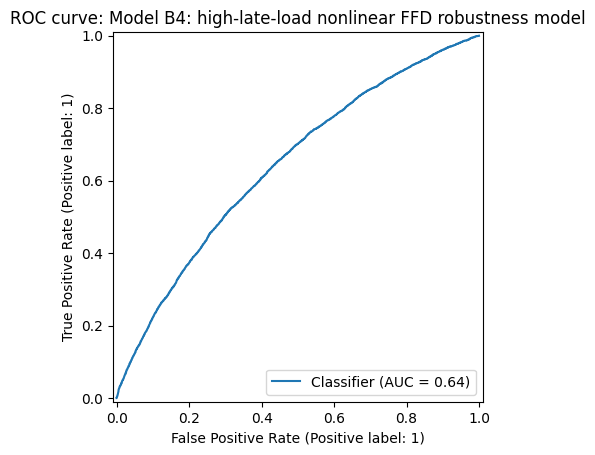

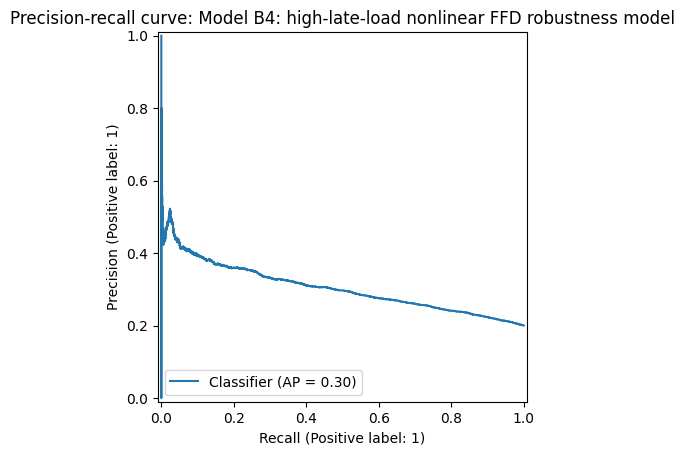

In [ ]:
assert_no_target_leakage(
    "target_high_late_load",
    CONFIRMATORY_FFD_INTERACTION_NUMERIC + LEXICAL_CATEGORICAL
)

late_firstpass_model, late_firstpass_metrics, late_firstpass_pred = fit_and_evaluate_model(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=CONFIRMATORY_FFD_INTERACTION_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="logreg",
    model_name="Model B3: high-late-load moderated FFD logistic model"
)

assert_no_target_leakage(
    "target_high_late_load",
    CONFIRMATORY_FFD_NONLINEAR_NUMERIC + LEXICAL_CATEGORICAL
)

late_rf_model, late_rf_metrics, late_rf_pred = fit_and_evaluate_model(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=CONFIRMATORY_FFD_NONLINEAR_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="rf",
    model_name="Model B4: high-late-load nonlinear FFD robustness model"
)

# 16. Unified B-series performance table

This section reframes the output as a single evidence ladder for the same question:

> **Does FFD-based early fixation information robustly improve prediction of high late processing load beyond lexical/contextual features?**

The evidence structure is:

```text
B0: no-signal reference
B1: lexical/contextual baseline
B2: additive FFD improvement
B3: moderated FFD robustness
B4: nonlinear FFD robustness
```

A strong result is not just “one model is best.”  
A strong result is a consistent pattern showing that FFD-based models improve over B1 across several specifications.

In [ ]:
metric_objects = [
    skip_dummy_metrics,
    skip_logreg_metrics,
    skip_rf_metrics,
    late_dummy_metrics,
    late_lex_metrics,
    late_early_metrics,
    late_firstpass_metrics,
    late_rf_metrics
]

metric_objects = [m for m in metric_objects if isinstance(m, dict)]

B_MODEL_METADATA = pd.DataFrame([
    {
        "model": "Model B0: high-late-load dummy baseline",
        "model_code": "B0",
        "evidence_order": 0,
        "evidence_role": "no-signal reference",
        "research_question_role": "Can any real model beat trivial prediction?",
        "feature_family": "none / majority class"
    },
    {
        "model": "Model B1: high-late-load lexical baseline",
        "model_code": "B1",
        "evidence_order": 1,
        "evidence_role": "lexical/contextual baseline",
        "research_question_role": "How much late load is predictable without eye-tracking?",
        "feature_family": "lexical/contextual"
    },
    {
        "model": "Model B2: high-late-load lexical + FFD model",
        "model_code": "B2",
        "evidence_order": 2,
        "evidence_role": "additive FFD test",
        "research_question_role": "Does FFD add predictive value beyond B1?",
        "feature_family": "lexical/contextual + FFD"
    },
    {
        "model": "Model B3: high-late-load moderated FFD logistic model",
        "model_code": "B3",
        "evidence_order": 3,
        "evidence_role": "context-moderated FFD robustness",
        "research_question_role": "Does the FFD signal remain useful when context interactions are allowed?",
        "feature_family": "lexical/contextual + FFD + FFD×context"
    },
    {
        "model": "Model B4: high-late-load nonlinear FFD robustness model",
        "model_code": "B4",
        "evidence_order": 4,
        "evidence_role": "nonlinear FFD robustness",
        "research_question_role": "Does the FFD signal remain useful under a nonlinear classifier?",
        "feature_family": "lexical/contextual + FFD, nonlinear"
    },
])

if len(metric_objects) == 0:
    print("No model metrics were produced. Check target distributions and file availability.")
    all_metrics = pd.DataFrame()
    b_metrics = pd.DataFrame()
else:
    all_metrics = pd.DataFrame(metric_objects)

    metric_order = [
        "model", "target", "model_type", "group_col",
        "accuracy", "balanced_accuracy", "precision",
        "recall", "f1", "roc_auc", "average_precision", "brier_score",
        "decision_threshold", "validation_score", "n_validation",
        "selected_params", "hyperparameter_tuned", "threshold_tuned",
        "n_train", "n_test", "n_train_groups", "n_test_groups",
        "positive_rate_train", "positive_rate_test"
    ]

    all_metrics = all_metrics[[c for c in metric_order if c in all_metrics.columns]]
    all_metrics = all_metrics.merge(B_MODEL_METADATA, on="model", how="left")

    b_metrics = (
        all_metrics[all_metrics["target"].eq("target_high_late_load")]
        .sort_values("evidence_order", na_position="last")
        .reset_index(drop=True)
    )

    print("Unified B-series evidence table:")
    display_cols = [
        "model_code", "evidence_role", "feature_family",
        "balanced_accuracy", "f1", "roc_auc", "average_precision", "brier_score",
        "decision_threshold", "validation_score", "precision", "recall",
        "n_validation", "n_test", "positive_rate_test"
    ]
    display(b_metrics[[c for c in display_cols if c in b_metrics.columns]])

    print("All model metrics, including skipping models:")
    display(all_metrics.sort_values(["target", "balanced_accuracy"], ascending=[True, False]))

    model_comparison_path = OUTPUT_DIR / "model_comparison_metrics_all.csv"
    all_metrics.to_csv(model_comparison_path, index=False)
    print("Saved:", model_comparison_path)

    b_metrics_path = OUTPUT_DIR / "model_B_series_aligned_metrics.csv"
    b_metrics.to_csv(b_metrics_path, index=False)
    print("Saved:", b_metrics_path)

Unified B-series evidence table:


,model_code,evidence_role,feature_family,balanced_accuracy,f1,roc_auc,average_precision,brier_score,decision_threshold,validation_score,precision,recall,n_validation,n_test,positive_rate_test
0,B0,no-signal reference,none / majority class,0.500000,0.000000,0.500000,0.200012,0.200012,0.500,0.500000,0.000000,0.000000,19671,33533,0.200012
1,B1,lexical/contextual baseline,lexical/contextual,0.590282,0.365696,0.626353,0.294502,0.154747,0.200,0.599640,0.264578,0.591919,19671,33533,0.200012
2,B2,additive FFD test,lexical/contextual + FFD,0.594422,0.366960,0.630216,0.296204,0.236952,0.525,0.601278,0.277076,0.543164,19671,33533,0.200012
3,B3,context-moderated FFD robustness,lexical/contextual + FFD + FFD×context,0.595763,0.368676,0.632298,0.296765,0.236656,0.525,0.603272,0.277185,0.550321,19671,33533,0.200012
4,B4,nonlinear FFD robustness,"lexical/contextual + FFD, nonlinear",0.603349,0.376839,0.642929,0.304064,0.228784,0.500,0.606854,0.283124,0.563292,19671,33533,0.200012


All model metrics, including skipping models:


,model,target,model_type,group_col,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,model_code,evidence_order,evidence_role,research_question_role,feature_family
7,Model B4: high-late-load nonlinear FFD robustness model,target_high_late_load,rf,sentence_hash,0.627382,0.603349,0.283124,0.563292,0.376839,0.642929,0.304064,0.228784,0.500,0.606854,19671,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.6, 'classifier__class_weight': 'balanced'}",True,True,104093,33533,497,166,0.195248,0.200012,B4,4.0,nonlinear FFD robustness,Does the FFD signal remain useful under a nonlinear classifier?,"lexical/contextual + FFD, nonlinear"
6,Model B3: high-late-load moderated FFD logistic model,target_high_late_load,logreg,sentence_hash,0.623028,0.595763,0.277185,0.550321,0.368676,0.632298,0.296765,0.236656,0.525,0.603272,19671,"{'classifier__C': 0.3, 'classifier__class_weight': 'balanced'}",True,True,104093,33533,497,166,0.195248,0.200012,B3,3.0,context-moderated FFD robustness,Does the FFD signal remain useful when context interactions are allowed?,lexical/contextual + FFD + FFD×context
5,Model B2: high-late-load lexical + FFD model,target_high_late_load,logreg,sentence_hash,0.625175,0.594422,0.277076,0.543164,0.366960,0.630216,0.296204,0.236952,0.525,0.601278,19671,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}",True,True,104093,33533,497,166,0.195248,0.200012,B2,2.0,additive FFD test,Does FFD add predictive value beyond B1?,lexical/contextual + FFD
4,Model B1: high-late-load lexical baseline,target_high_late_load,logreg,sentence_hash,0.589300,0.590282,0.264578,0.591919,0.365696,0.626353,0.294502,0.154747,0.200,0.599640,19671,"{'classifier__C': 0.05, 'classifier__class_weight': None}",True,True,104093,33533,497,166,0.195248,0.200012,B1,1.0,lexical/contextual baseline,How much late load is predictable without eye-tracking?,lexical/contextual
3,Model B0: high-late-load dummy baseline,target_high_late_load,dummy,sentence_hash,0.799988,0.500000,0.000000,0.000000,0.000000,0.500000,0.200012,0.200012,0.500,0.500000,19671,{},False,False,104093,33533,497,166,0.195248,0.200012,B0,0.0,no-signal reference,Can any real model beat trivial prediction?,none / majority class
2,Model A2: skipped-word lexical random forest,target_skipped,rf,sentence_hash,0.698181,0.691572,0.611270,0.659440,0.634442,0.754288,0.652400,0.202247,0.525,0.694621,33340,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanc...",True,True,174776,55626,497,166,0.404421,0.397170,NaN,NaN,NaN,NaN,NaN
1,Model A1: skipped-word lexical logistic regression,target_skipped,logreg,sentence_hash,0.682738,0.689149,0.581163,0.720319,0.643302,0.747034,0.637451,0.204591,0.475,0.696780,33340,"{'classifier__C': 0.05, 'classifier__class_weight': 'balanced'}",True,True,174776,55626,497,166,0.404421,0.397170,NaN,NaN,NaN,NaN,NaN
0,Model A0: skipped-word dummy baseline,target_skipped,dummy,sentence_hash,0.602830,0.500000,0.000000,0.000000,0.000000,0.500000,0.397170,0.397170,0.500,0.500000,33340,{},False,False,174776,55626,497,166,0.404421,0.397170,NaN,NaN,NaN,NaN,NaN


Saved: /content/drive/MyDrive/ZuCo/outputs/model_comparison_metrics_all.csv
Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_aligned_metrics.csv


# 16A. Accuracy optimisation diagnostics

This section reports **how** the models were optimised.

Statistical interpretation:

- `decision_threshold` is the probability cut-off selected on validation data.
- `validation_score` is the score used to select threshold/hyperparameters.
- `selected_params` shows the chosen model complexity.
- A test metric is only credible if the threshold and hyperparameters were not chosen using the test set.

Use this table to check whether improved accuracy came from:

```text
better features
better threshold
better regularisation/model complexity
```

In [ ]:
if "b_metrics" not in globals() or b_metrics.empty:
    print("No B-series metrics available yet.")
else:
    diagnostic_cols = [
        "model_code", "evidence_role", "decision_threshold", "validation_score",
        "selected_params", "hyperparameter_tuned", "threshold_tuned",
        "balanced_accuracy", "f1", "roc_auc", "average_precision", "brier_score"
    ]
    diagnostic_cols = [c for c in diagnostic_cols if c in b_metrics.columns]

    print("Accuracy optimisation diagnostics for B-series models:")
    display(b_metrics[diagnostic_cols])

    print("\nStraight statistical reading:")
    print("- Higher balanced_accuracy means better class-balanced test performance.")
    print("- Higher F1 means better positive-class detection under the chosen threshold.")
    print("- Higher ROC-AUC means better probability ranking, independent of a single threshold.")
    print("- Lower Brier score means better calibrated probabilities.")
    print("- Compare B2/B3/B4 against B1, not only against B0.")

Accuracy optimisation diagnostics for B-series models:


,model_code,evidence_role,decision_threshold,validation_score,selected_params,hyperparameter_tuned,threshold_tuned,balanced_accuracy,f1,roc_auc,average_precision,brier_score
0,B0,no-signal reference,0.500,0.500000,{},False,False,0.500000,0.000000,0.500000,0.200012,0.200012
1,B1,lexical/contextual baseline,0.200,0.599640,"{'classifier__C': 0.05, 'classifier__class_weight': None}",True,True,0.590282,0.365696,0.626353,0.294502,0.154747
2,B2,additive FFD test,0.525,0.601278,"{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}",True,True,0.594422,0.366960,0.630216,0.296204,0.236952
3,B3,context-moderated FFD robustness,0.525,0.603272,"{'classifier__C': 0.3, 'classifier__class_weight': 'balanced'}",True,True,0.595763,0.368676,0.632298,0.296765,0.236656
4,B4,nonlinear FFD robustness,0.500,0.606854,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.6, 'classifier__class_weight': 'balanced'}",True,True,0.603349,0.376839,0.642929,0.304064,0.228784



Straight statistical reading:
- Higher balanced_accuracy means better class-balanced test performance.
- Higher F1 means better positive-class detection under the chosen threshold.
- Higher ROC-AUC means better probability ranking, independent of a single threshold.
- Lower Brier score means better calibrated probabilities.
- Compare B2/B3/B4 against B1, not only against B0.


# 17. Pairwise statistical comparison across the aligned B-series

The previous version compared only:

```text
B1 vs B2
```

This version compares the aligned robustness ladder:

```text
B1 vs B2
B1 vs B3
B1 vs B4
B2 vs B3
B2 vs B4
```

These comparisons all answer the same question:

> Does FFD-based early-fixation information improve prediction beyond lexical/contextual features, and is that improvement stable across specifications?

McNemar's test checks whether two models make different correct/wrong decisions on the same held-out words.

In [ ]:
def mcnemar_test_from_predictions(y_true, pred_a, pred_b):
    """
    Approximate McNemar test with continuity correction.
    """
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    b = np.sum(a_correct & ~b_correct)
    c = np.sum(~a_correct & b_correct)

    if b + c == 0:
        chi2 = 0.0
        p_value = 1.0
    else:
        chi2 = (abs(b - c) - 1) ** 2 / (b + c)
        p_value = 1 - stats.chi2.cdf(chi2, df=1)

    return {
        "A_correct_B_wrong": int(b),
        "A_wrong_B_correct": int(c),
        "mcnemar_chi2": chi2,
        "p_value": p_value
    }


B_PREDICTION_REGISTRY = {
    "B1": {
        "label": "lexical baseline",
        "pred_df": late_lex_pred
    },
    "B2": {
        "label": "additive FFD",
        "pred_df": late_early_pred
    },
    "B3": {
        "label": "moderated FFD",
        "pred_df": late_firstpass_pred
    },
    "B4": {
        "label": "nonlinear FFD",
        "pred_df": late_rf_pred
    },
}

B_PAIRWISE_COMPARISONS = [
    ("B1", "B2"),
    ("B1", "B3"),
    ("B1", "B4"),
    ("B2", "B3"),
    ("B2", "B4"),
]


def align_two_prediction_tables(model_a_key, model_b_key):
    """
    Align two held-out prediction tables on the same word rows.
    """
    pred_a = B_PREDICTION_REGISTRY[model_a_key]["pred_df"]
    pred_b = B_PREDICTION_REGISTRY[model_b_key]["pred_df"]

    if pred_a is None or pred_b is None:
        return pd.DataFrame()

    target_col = "target_high_late_load"
    pred_col = "pred_target_high_late_load"

    id_cols = ["subject_id", "task", "sentence_id", "word_id", GROUP_COL_FOR_VALIDATION]
    id_cols = [c for c in dict.fromkeys(id_cols) if c in pred_a.columns and c in pred_b.columns]

    a = pred_a[id_cols + [target_col, pred_col]].copy()
    a = a.rename(columns={
        target_col: "target",
        pred_col: f"pred_{model_a_key}"
    })

    b = pred_b[id_cols + [pred_col]].copy()
    b = b.rename(columns={
        pred_col: f"pred_{model_b_key}"
    })

    aligned = a.merge(b, on=id_cols, how="inner")
    aligned["comparison"] = f"{model_b_key} minus {model_a_key}"
    aligned["model_A"] = model_a_key
    aligned["model_B"] = model_b_key

    return aligned


mcnemar_rows = []

for model_a, model_b in B_PAIRWISE_COMPARISONS:
    aligned = align_two_prediction_tables(model_a, model_b)

    if aligned.empty:
        print(f"McNemar skipped for {model_a} vs {model_b}: predictions unavailable or not alignable.")
        continue

    result = mcnemar_test_from_predictions(
        y_true=aligned["target"],
        pred_a=aligned[f"pred_{model_a}"],
        pred_b=aligned[f"pred_{model_b}"]
    )
    result.update({
        "comparison": f"{model_b} minus {model_a}",
        "model_A": model_a,
        "model_B": model_b,
        "n_aligned_rows": len(aligned)
    })
    mcnemar_rows.append(result)

mcnemar_df = pd.DataFrame(mcnemar_rows)

if mcnemar_df.empty:
    print("No McNemar comparisons were produced.")
else:
    display(mcnemar_df)
    mcnemar_path = OUTPUT_DIR / "model_B_series_mcnemar_comparisons.csv"
    mcnemar_df.to_csv(mcnemar_path, index=False)
    print("Saved:", mcnemar_path)

,A_correct_B_wrong,A_wrong_B_correct,mcnemar_chi2,p_value,comparison,model_A,model_B,n_aligned_rows
0,673,1876,566.812083,0.000000,B2 minus B1,B1,B2,33533
1,778,1909,475.213993,0.000000,B3 minus B1,B1,B3,33533
2,1588,2865,365.635751,0.000000,B4 minus B1,B1,B4,33533
3,529,457,5.112576,0.023753,B3 minus B2,B2,B3,33533
4,1973,2047,1.325622,0.249586,B4 minus B2,B2,B4,33533


Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_mcnemar_comparisons.csv


# 17A. Paired grouped bootstrap across the aligned B-series

McNemar's test checks error-pattern differences.  
The paired grouped bootstrap estimates uncertainty around the **metric difference**:

```text
balanced_accuracy(model_B) - balanced_accuracy(model_A)
```

The bootstrap samples validation groups, not individual word rows, which better respects the grouped design.

The key comparisons are:

```text
B2 - B1
B3 - B1
B4 - B1
```

If all or most are positive, the evidence for FFD-based predictive value is more robust.

In [ ]:
def grouped_bootstrap_metric_difference(
    aligned_pred_df,
    target_col,
    pred_a_col,
    pred_b_col,
    group_col,
    metric_func=balanced_accuracy_score,
    n_boot=1000,
    random_state=RANDOM_STATE
):
    """
    Paired grouped bootstrap for metric difference B - A.
    """
    if aligned_pred_df is None or aligned_pred_df.empty:
        return pd.DataFrame()

    rng = np.random.default_rng(random_state)
    groups = aligned_pred_df[group_col].dropna().unique()

    if len(groups) < 2:
        return pd.DataFrame()

    deltas = []

    for _ in range(n_boot):
        sampled_groups = rng.choice(groups, size=len(groups), replace=True)
        sample = pd.concat([
            aligned_pred_df[aligned_pred_df[group_col] == g]
            for g in sampled_groups
        ], ignore_index=True)

        y_true = sample[target_col].astype(int).values
        pred_a = sample[pred_a_col].astype(int).values
        pred_b = sample[pred_b_col].astype(int).values

        if len(np.unique(y_true)) < 2:
            continue

        delta = metric_func(y_true, pred_b) - metric_func(y_true, pred_a)
        deltas.append(delta)

    if len(deltas) == 0:
        return pd.DataFrame()

    deltas = np.asarray(deltas)

    return pd.DataFrame([{
        "metric": getattr(metric_func, "__name__", "metric"),
        "mean_delta": float(np.mean(deltas)),
        "ci_low": float(np.quantile(deltas, 0.025)),
        "ci_high": float(np.quantile(deltas, 0.975)),
        "p_delta_le_0": float(np.mean(deltas <= 0)),
        "n_boot_valid": len(deltas),
        "group_col": group_col
    }])


bootstrap_comparison_rows = []

for model_a, model_b in B_PAIRWISE_COMPARISONS:
    aligned = align_two_prediction_tables(model_a, model_b)

    if aligned.empty or GROUP_COL_FOR_VALIDATION not in aligned.columns:
        print(f"Bootstrap skipped for {model_a} vs {model_b}: predictions unavailable or group column missing.")
        continue

    boot = grouped_bootstrap_metric_difference(
        aligned_pred_df=aligned,
        target_col="target",
        pred_a_col=f"pred_{model_a}",
        pred_b_col=f"pred_{model_b}",
        group_col=GROUP_COL_FOR_VALIDATION,
        metric_func=balanced_accuracy_score,
        n_boot=1000
    )

    if boot.empty:
        continue

    boot["comparison"] = f"{model_b} minus {model_a}"
    boot["model_A"] = model_a
    boot["model_B"] = model_b
    boot["n_aligned_rows"] = len(aligned)
    bootstrap_comparison_rows.append(boot)

paired_bootstrap_delta_df = (
    pd.concat(bootstrap_comparison_rows, ignore_index=True)
    if bootstrap_comparison_rows else pd.DataFrame()
)

if paired_bootstrap_delta_df.empty:
    print("No paired grouped bootstrap comparisons were produced.")
else:
    display(paired_bootstrap_delta_df[[
        "comparison", "metric", "mean_delta", "ci_low", "ci_high",
        "p_delta_le_0", "n_boot_valid", "group_col", "n_aligned_rows"
    ]])

    paired_bootstrap_path = OUTPUT_DIR / "model_B_series_paired_grouped_bootstrap.csv"
    paired_bootstrap_delta_df.to_csv(paired_bootstrap_path, index=False)
    print("Saved:", paired_bootstrap_path)

,comparison,metric,mean_delta,ci_low,ci_high,p_delta_le_0,n_boot_valid,group_col,n_aligned_rows
0,B2 minus B1,balanced_accuracy_score,0.004120,-0.000316,0.008233,0.031,1000,sentence_hash,33533
1,B3 minus B1,balanced_accuracy_score,0.005471,0.001272,0.009699,0.005,1000,sentence_hash,33533
2,B4 minus B1,balanced_accuracy_score,0.013038,0.006722,0.019754,0.000,1000,sentence_hash,33533
3,B3 minus B2,balanced_accuracy_score,0.001351,-0.001065,0.003762,0.135,1000,sentence_hash,33533
4,B4 minus B2,balanced_accuracy_score,0.008918,0.002937,0.014726,0.001,1000,sentence_hash,33533


Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_paired_grouped_bootstrap.csv


# 18. Feature interpretation across the aligned B-series

Model performance tells us whether prediction works.  
Feature interpretation tells us **what evidence the models used**.

This section interprets the aligned B models as one suite:

```text
B1: lexical/contextual baseline
B2: additive FFD evidence
B3: FFD evidence with context moderation
B4: nonlinear FFD evidence
```

Use the interpretation outputs to ask:

> Is FFD itself important?  
> Are FFD interactions important?  
> Do nonlinear models rely on the same FFD signal or mostly on lexical features?

In [ ]:
def get_feature_names_from_pipeline(pipeline):
    """
    Extract final feature names after preprocessing.
    """
    preprocessor = pipeline.named_steps["preprocess"]
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "num":
            feature_names.extend(columns)
        elif name == "cat":
            try:
                onehot = transformer.named_steps["onehot"]
                feature_names.extend(onehot.get_feature_names_out(columns))
            except Exception:
                feature_names.extend(columns)

    return np.array(feature_names)


def logistic_coefficient_table(pipeline, model_code=None, model_label=None):
    """
    Return coefficients for a fitted logistic-regression pipeline.
    """
    if pipeline is None:
        return pd.DataFrame()

    classifier = pipeline.named_steps["classifier"]

    if not hasattr(classifier, "coef_"):
        return pd.DataFrame()

    feature_names = get_feature_names_from_pipeline(pipeline)
    coefs = classifier.coef_[0]

    out = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefs,
            "abs_coefficient": np.abs(coefs)
        })
        .sort_values("abs_coefficient", ascending=False)
    )

    if model_code is not None:
        out.insert(0, "model_code", model_code)
    if model_label is not None:
        out.insert(1, "model_label", model_label)

    return out


coefficient_tables = []

for model_code, model_label, model_obj in [
    ("B1", "lexical baseline", late_lex_model),
    ("B2", "additive FFD", late_early_model),
    ("B3", "moderated FFD", late_firstpass_model),
]:
    coef_table = logistic_coefficient_table(model_obj, model_code=model_code, model_label=model_label)
    if not coef_table.empty:
        coefficient_tables.append(coef_table)

if not coefficient_tables:
    print("Coefficient tables skipped because no fitted logistic B models are available.")
    b_series_coef_df = pd.DataFrame()
else:
    b_series_coef_df = pd.concat(coefficient_tables, ignore_index=True)

    print("Top coefficients by B-series logistic model:")
    display(
        b_series_coef_df
        .sort_values(["model_code", "abs_coefficient"], ascending=[True, False])
        .groupby("model_code")
        .head(15)
        .reset_index(drop=True)
    )

    coef_path = OUTPUT_DIR / "model_B_series_logistic_coefficients.csv"
    b_series_coef_df.to_csv(coef_path, index=False)
    print("Saved:", coef_path)

Top coefficients by B-series logistic model:


,model_code,model_label,feature,coefficient,abs_coefficient
0,B1,lexical baseline,task_TSR,-0.528842,0.528842
1,B1,lexical baseline,task_NR,-0.383546,0.383546
2,B1,lexical baseline,word_position_norm,-0.351788,0.351788
3,B1,lexical baseline,log_word_length,0.310159,0.310159
4,B1,lexical baseline,sentence_length_words,-0.136808,0.136808
5,B1,lexical baseline,is_stopword,-0.065567,0.065567
6,B1,lexical baseline,has_digit,0.060650,0.060650
7,B1,lexical baseline,word_length,-0.047019,0.047019
8,B1,lexical baseline,is_capitalized,0.046303,0.046303
9,B1,lexical baseline,is_numeric,0.038882,0.038882


Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_logistic_coefficients.csv


Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005
Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005
Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005
Grouped split for target_high_late_load: seed=42, train positive rate=0.195, test positive rate=0.200, absolute difference=0.005


,model_code,model_label,feature,importance_mean,importance_std
0,B1,lexical baseline,word_position_norm,0.000000,0.000000
1,B1,lexical baseline,is_stopword,0.000000,0.000000
2,B1,lexical baseline,has_digit,0.000000,0.000000
3,B1,lexical baseline,is_capitalized,0.000000,0.000000
4,B1,lexical baseline,is_short_word,0.000000,0.000000
...,...,...,...,...,...
62,B4,nonlinear FFD,is_numeric,0.000577,0.000234
63,B4,nonlinear FFD,is_sentence_initial,0.000521,0.000123
64,B4,nonlinear FFD,log_FFD,0.000338,0.000610
65,B4,nonlinear FFD,is_short_word,0.000134,0.000600


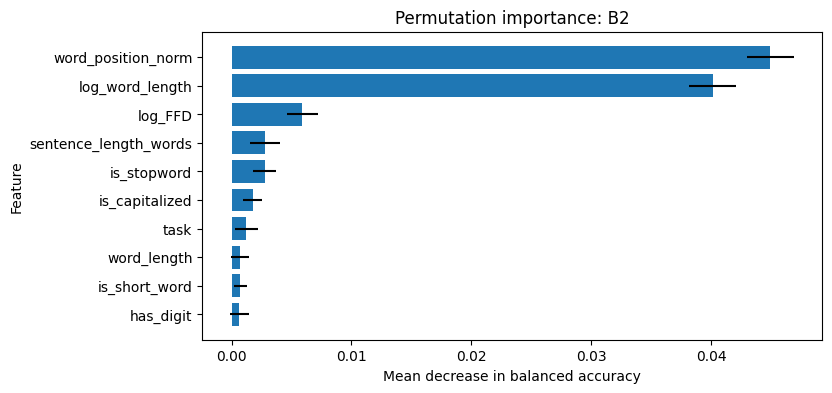

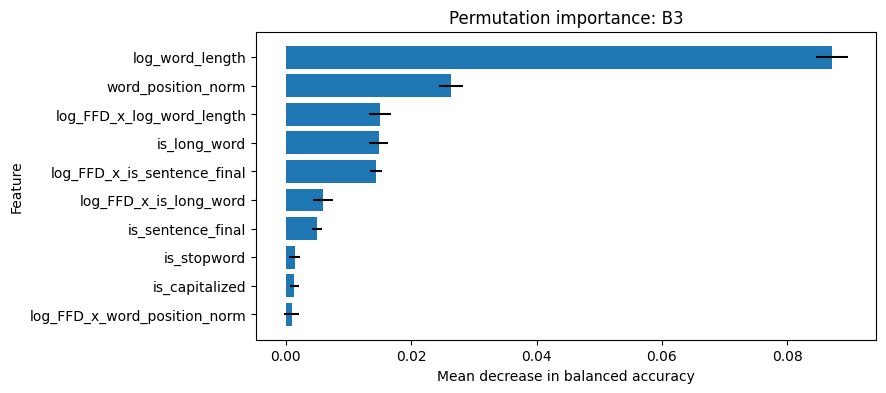

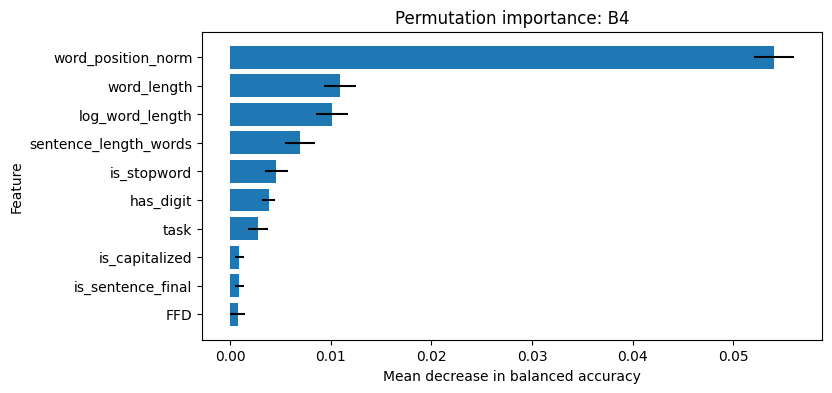

Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_permutation_importance.csv


In [ ]:
PERMUTATION_MODEL_SPECS = [
    ("B1", "lexical baseline", late_lex_model, LEXICAL_NUMERIC, LEXICAL_CATEGORICAL),
    ("B2", "additive FFD", late_early_model, EARLY_EYE_NUMERIC, LEXICAL_CATEGORICAL),
    ("B3", "moderated FFD", late_firstpass_model, CONFIRMATORY_FFD_INTERACTION_NUMERIC, LEXICAL_CATEGORICAL),
    ("B4", "nonlinear FFD", late_rf_model, CONFIRMATORY_FFD_NONLINEAR_NUMERIC, LEXICAL_CATEGORICAL),
]

perm_tables = []

for model_code, model_label, model_obj, numeric_features, categorical_features in PERMUTATION_MODEL_SPECS:
    if model_obj is None:
        print(f"Permutation importance skipped for {model_code}: model not fitted.")
        continue

    train_tmp, test_tmp = choose_group_train_test_split(
        df=late_df,
        target_col="target_high_late_load",
        group_col=GROUP_COL_FOR_VALIDATION,
        test_size=0.25,
        random_state=RANDOM_STATE
    )

    features = numeric_features + categorical_features
    X_test_tmp = test_tmp[features]
    y_test_tmp = test_tmp["target_high_late_load"].astype(int)

    perm = permutation_importance(
        model_obj,
        X_test_tmp,
        y_test_tmp,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="balanced_accuracy"
    )

    perm_df_tmp = pd.DataFrame({
        "model_code": model_code,
        "model_label": model_label,
        "feature": X_test_tmp.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values(["model_code", "importance_mean"], ascending=[True, False])

    perm_tables.append(perm_df_tmp)

if not perm_tables:
    print("No permutation-importance tables were produced.")
    perm_df = pd.DataFrame()
else:
    perm_df = pd.concat(perm_tables, ignore_index=True)
    display(perm_df.sort_values(["model_code", "importance_mean"], ascending=[True, False]))

    # Plot top features from B2-B4 because those are the FFD-bearing models.
    top_perm = (
        perm_df[perm_df["model_code"].isin(["B2", "B3", "B4"])]
        .sort_values(["model_code", "importance_mean"], ascending=[True, False])
        .groupby("model_code")
        .head(10)
    )

    for model_code, group in top_perm.groupby("model_code"):
        plt.figure(figsize=(8, 4))
        group_sorted = group.sort_values("importance_mean", ascending=True)
        plt.barh(group_sorted["feature"], group_sorted["importance_mean"], xerr=group_sorted["importance_std"])
        plt.xlabel("Mean decrease in balanced accuracy")
        plt.ylabel("Feature")
        plt.title(f"Permutation importance: {model_code}")
        plt.show()

    perm_path = OUTPUT_DIR / "model_B_series_permutation_importance.csv"
    perm_df.to_csv(perm_path, index=False)
    print("Saved:", perm_path)

# 18A. Error analysis across the aligned B-series

Model interpretation should include error inspection, not only summary metrics.

This section compares error rates across B1–B4 and then inspects B2 as the theory-primary FFD model.

Use this to ask:

- Do FFD models reduce false negatives for high late-load words?
- Do errors concentrate on long words, sentence-final words, or a specific task?
- Does the nonlinear model make different kinds of errors from the additive FFD model?

In [ ]:
def add_error_labels(pred_df, model_code):
    """
    Add error labels to a prediction table for target_high_late_load.
    """
    if pred_df is None:
        return pd.DataFrame()

    pred_col = "pred_target_high_late_load"
    prob_col = "prob_target_high_late_load"

    out = pred_df.copy()
    out["model_code"] = model_code
    out["error_type"] = "correct"
    out.loc[(out["target_high_late_load"] == 0) & (out[pred_col] == 1), "error_type"] = "false_positive"
    out.loc[(out["target_high_late_load"] == 1) & (out[pred_col] == 0), "error_type"] = "false_negative"

    if prob_col not in out.columns:
        out[prob_col] = np.nan

    return out


error_tables = []

for model_code, registry in B_PREDICTION_REGISTRY.items():
    tmp = add_error_labels(registry["pred_df"], model_code)
    if not tmp.empty:
        error_tables.append(tmp)

if not error_tables:
    print("Error analysis skipped because no B-series predictions are available.")
    error_df = pd.DataFrame()
else:
    error_df = pd.concat(error_tables, ignore_index=True)

    print("Error counts by model:")
    display(
        error_df
        .groupby(["model_code", "error_type"])
        .size()
        .rename("n")
        .reset_index()
    )

    print("Error rates by model and task:")
    display(
        error_df
        .assign(is_error=lambda d: (d["error_type"] != "correct").astype(int))
        .groupby(["model_code", "task"])
        .agg(
            n=("word", "count"),
            error_rate=("is_error", "mean"),
            false_negative_rate=("error_type", lambda x: np.mean(x == "false_negative")),
            false_positive_rate=("error_type", lambda x: np.mean(x == "false_positive")),
            mean_word_length=("word_length", "mean"),
            mean_FFD=("FFD", "mean"),
            mean_late_time=("late_time", "mean")
        )
        .reset_index()
    )

    inspect_cols = [
        "model_code", "subject_id", "task", "sentence_id", "word_id", "word",
        "word_length", "FFD", "GD", "TRT", "late_time",
        "target_high_late_load", "pred_target_high_late_load",
        "prob_target_high_late_load", "error_type"
    ]
    inspect_cols = [c for c in inspect_cols if c in error_df.columns]

    print("Theory-primary B2 false negatives:")
    display(
        error_df[(error_df["model_code"] == "B2") & (error_df["error_type"] == "false_negative")]
        [inspect_cols]
        .sort_values("prob_target_high_late_load", ascending=True)
        .head(20)
    )

    print("Theory-primary B2 false positives:")
    display(
        error_df[(error_df["model_code"] == "B2") & (error_df["error_type"] == "false_positive")]
        [inspect_cols]
        .sort_values("prob_target_high_late_load", ascending=False)
        .head(20)
    )

    error_path = OUTPUT_DIR / "model_B_series_error_analysis.csv"
    error_df.to_csv(error_path, index=False)
    print("Saved:", error_path)

Error counts by model:


,model_code,error_type,n
0,B1,correct,19761
1,B1,false_negative,2737
2,B1,false_positive,11035
3,B2,correct,20964
4,B2,false_negative,3064
5,B2,false_positive,9505
6,B3,correct,20892
7,B3,false_negative,3016
8,B3,false_positive,9625
9,B4,correct,21038


Error rates by model and task:


,model_code,task,n,error_rate,false_negative_rate,false_positive_rate,mean_word_length,mean_FFD,mean_late_time
0,B1,NR,16960,0.425295,0.072759,0.352535,5.690861,115.056368,41.361910
1,B1,TSR,16573,0.395764,0.090690,0.305075,5.895674,114.191577,43.864659
2,B2,NR,16960,0.386557,0.082606,0.303950,5.690861,115.056368,41.361910
3,B2,TSR,16573,0.362819,0.100344,0.262475,5.895674,114.191577,43.864659
4,B3,NR,16960,0.387264,0.081309,0.305955,5.690861,115.056368,41.361910
5,B3,TSR,16573,0.366439,0.098775,0.267664,5.895674,114.191577,43.864659
6,B4,NR,16960,0.381958,0.081781,0.300177,5.690861,115.056368,41.361910
7,B4,TSR,16573,0.363060,0.093043,0.270017,5.895674,114.191577,43.864659


Theory-primary B2 false negatives:


,model_code,subject_id,task,sentence_id,word_id,word,word_length,FFD,GD,TRT,late_time,target_high_late_load,pred_target_high_late_load,prob_target_high_late_load,error_type
56497,B2,YRK,TSR,101,34,a,1,132.0,132.0,214.0,82.0,1,0,0.142860,false_negative
53913,B2,YMD,TSR,117,34,a,1,86.0,86.0,207.0,121.0,1,0,0.161202,false_negative
58871,B2,YRP,TSR,68,14,a,1,197.0,197.0,294.0,97.0,1,0,0.176481,false_negative
37725,B2,YAG,NR,55,41,the,3,201.0,201.0,304.0,103.0,1,0,0.192331,false_negative
50124,B2,YLS,TSR,333,11,a,1,131.0,131.0,268.0,137.0,1,0,0.192512,false_negative
66975,B2,YTL,TSR,333,11,a,1,127.0,127.0,258.0,131.0,1,0,0.193905,false_negative
63707,B2,YSL,TSR,46,27,by,2,143.0,143.0,223.0,80.0,1,0,0.194184,false_negative
38012,B2,YAG,NR,114,30,he,2,220.0,220.0,429.0,209.0,1,0,0.194896,false_negative
47298,B2,YHS,NR,55,41,the,3,183.0,183.0,292.0,109.0,1,0,0.196609,false_negative
37038,B2,YAK,TSR,209,36,she,3,136.0,136.0,212.0,76.0,1,0,0.198828,false_negative


Theory-primary B2 false positives:


,model_code,subject_id,task,sentence_id,word_id,word,word_length,FFD,GD,TRT,late_time,target_high_late_load,pred_target_high_late_load,prob_target_high_late_load,error_type
44404,B2,YFR,NR,198,2,"great-grandfather,",18,51.0,51.0,51.0,0.0,0,1,0.793922,false_positive
52434,B2,YMD,NR,89,1,"2005-04-12,",11,52.0,936.0,1017.0,81.0,0,1,0.790345,false_positive
47343,B2,YHS,NR,75,1,1955,4,53.0,53.0,53.0,0.0,0,1,0.782242,false_positive
42791,B2,YDR,NR,198,2,"great-grandfather,",18,72.0,72.0,72.0,0.0,0,1,0.777460,false_positive
54853,B2,YRK,NR,35,1,1966,4,59.0,335.0,335.0,0.0,0,1,0.777026,false_positive
37598,B2,YAG,NR,35,1,1966,4,64.0,195.0,195.0,0.0,0,1,0.773002,false_positive
55092,B2,YRK,NR,89,1,"2005-04-12,",11,77.0,166.0,252.0,86.0,0,1,0.771281,false_positive
34189,B2,YAC,NR,198,2,"great-grandfather,",18,89.0,192.0,192.0,0.0,0,1,0.766818,false_positive
46870,B2,YFS,TSR,182,2,"Bulwer-Lytton,",14,54.0,54.0,54.0,0.0,0,1,0.762278,false_positive
62931,B2,YSL,NR,198,2,"great-grandfather,",18,100.0,710.0,710.0,0.0,0,1,0.760797,false_positive


Saved: /content/drive/MyDrive/ZuCo/outputs/model_B_series_error_analysis.csv


# 19. Cross-validation for the aligned B-series with inner validation tuning

A single train/test split can be unstable.

This section performs grouped cross-validation where each fold uses:

```text
fold training data   -> fit model
inner validation     -> tune threshold/hyperparameters
fold test data       -> evaluate
```

Statistical interpretation:

- This is more honest than tuning once on the full dataset.
- If B2/B3/B4 improve over B1 across folds, the FFD-based signal is more robust.
- If cross-validation performance is unstable, the model may be overfitting or the dataset may be too small.

In [ ]:
def grouped_cross_validation(
    df,
    target_col,
    numeric_features,
    categorical_features,
    model_type="logreg",
    group_col=None,
    max_splits=5
):
    """
    Grouped cross-validation with inner validation tuning.

    For each outer fold:
    - train/validation tuning happens only within the fold's training data
    - the fold test data remains unseen until final fold evaluation
    """
    if group_col is None:
        group_col = GROUP_COL_FOR_VALIDATION

    trainable, reason = is_trainable_binary_target(df, target_col)
    if not trainable:
        print(f"Cross-validation skipped for {target_col}: {reason}")
        return pd.DataFrame()

    data = df.dropna(subset=[target_col]).copy()
    data = data[data[group_col].notna()].copy()

    features = numeric_features + categorical_features
    assert_no_target_leakage(target_col, features)

    y = data[target_col].astype(int)
    groups = data[group_col]

    n_groups = groups.nunique()
    n_splits = min(max_splits, n_groups)

    if n_splits < 2:
        print("Cross-validation skipped: not enough groups.")
        return pd.DataFrame()

    cv = GroupKFold(n_splits=n_splits)

    fold_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, y, groups), start=1):
        train_valid_df = data.iloc[train_idx].copy()
        test_df = data.iloc[test_idx].copy()

        if train_valid_df[target_col].nunique() < 2 or test_df[target_col].nunique() < 2:
            continue

        model, tuning_info = fit_model_with_validation_tuning(
            train_valid_df=train_valid_df,
            target_col=target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            model_type=model_type,
            group_col=group_col,
            validation_size=VALIDATION_SIZE,
            random_state=RANDOM_STATE + fold_idx
        )

        X_test = test_df[features]
        y_test = test_df[target_col].astype(int)

        y_pred, y_score = predict_with_threshold(
            model,
            X_test,
            threshold=tuning_info["decision_threshold"]
        )

        metrics = safe_binary_metrics(y_test, y_pred, y_score)
        metrics.update({
            "fold": fold_idx,
            "n_test": len(test_df),
            "n_test_groups": test_df[group_col].nunique(),
            "positive_rate_test": y_test.mean(),
            "decision_threshold": tuning_info["decision_threshold"],
            "validation_score": tuning_info["validation_score"],
            "selected_params": str(tuning_info["selected_params"]),
            "model_type": model_type,
            "target": target_col,
            "group_col": group_col
        })
        fold_rows.append(metrics)

    if not fold_rows:
        return pd.DataFrame()

    fold_df = pd.DataFrame(fold_rows)

    summary_rows = []
    metric_names = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "brier_score"]

    for metric in metric_names:
        if metric in fold_df.columns:
            summary_rows.append({
                "metric": metric,
                "mean": fold_df[metric].mean(),
                "std": fold_df[metric].std(ddof=1),
                "n_splits": len(fold_df),
                "group_col": group_col,
                "model_type": model_type,
                "target": target_col
            })

    summary = pd.DataFrame(summary_rows)
    summary.attrs["fold_metrics"] = fold_df
    return summary


CV_B_MODEL_SPECS = [
    ("B1", "lexical baseline", LEXICAL_NUMERIC, LEXICAL_CATEGORICAL, "logreg"),
    ("B2", "additive FFD", EARLY_EYE_NUMERIC, LEXICAL_CATEGORICAL, "logreg"),
    ("B3", "moderated FFD", CONFIRMATORY_FFD_INTERACTION_NUMERIC, LEXICAL_CATEGORICAL, "logreg"),
    ("B4", "nonlinear FFD", CONFIRMATORY_FFD_NONLINEAR_NUMERIC, LEXICAL_CATEGORICAL, "rf"),
]

cv_tables = []
cv_fold_tables = []

for model_code, model_label, numeric_features, categorical_features, model_type in CV_B_MODEL_SPECS:
    cv_tmp = grouped_cross_validation(
        df=late_df,
        target_col="target_high_late_load",
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type
    )
    if not cv_tmp.empty:
        cv_tmp["model_code"] = model_code
        cv_tmp["model_label"] = model_label

        # Create a copy and clear attributes before appending to cv_tables
        # to avoid the ValueError during pd.concat due to DataFrame in attrs.
        summary_copy = cv_tmp.copy()
        summary_copy.attrs = {} # Clear attributes
        cv_tables.append(summary_copy)

        fold_df = cv_tmp.attrs.get("fold_metrics", pd.DataFrame())
        if not fold_df.empty:
            fold_df["model_code"] = model_code
            fold_df["model_label"] = model_label
            cv_fold_tables.append(fold_df)

cv_comparison = pd.concat(cv_tables, ignore_index=True) if cv_tables else pd.DataFrame()
cv_fold_metrics = pd.concat(cv_fold_tables, ignore_index=True) if cv_fold_tables else pd.DataFrame()

if cv_comparison.empty:
    print("No B-series cross-validation results produced.")
else:
    display(
        cv_comparison
        .sort_values(["metric", "model_code"])
        .reset_index(drop=True)
    )

    cv_path = OUTPUT_DIR / "cross_validation_B_series_inner_tuned_summary.csv"
    cv_comparison.to_csv(cv_path, index=False)
    print("Saved:", cv_path)

    if not cv_fold_metrics.empty:
        fold_path = OUTPUT_DIR / "cross_validation_B_series_inner_tuned_fold_metrics.csv"
        cv_fold_metrics.to_csv(fold_path, index=False)
        print("Saved fold-level CV metrics:", fold_path)

,metric,mean,std,n_splits,group_col,model_type,target,model_code,model_label
0,accuracy,0.588947,0.041728,5,sentence_hash,logreg,target_high_late_load,B1,lexical baseline
1,accuracy,0.606504,0.027185,5,sentence_hash,logreg,target_high_late_load,B2,additive FFD
2,accuracy,0.598991,0.022082,5,sentence_hash,logreg,target_high_late_load,B3,moderated FFD
3,accuracy,0.604890,0.031117,5,sentence_hash,rf,target_high_late_load,B4,nonlinear FFD
4,average_precision,0.292265,0.013127,5,sentence_hash,logreg,target_high_late_load,B1,lexical baseline
5,average_precision,0.297207,0.015468,5,sentence_hash,logreg,target_high_late_load,B2,additive FFD
6,average_precision,0.297256,0.014971,5,sentence_hash,logreg,target_high_late_load,B3,moderated FFD
7,average_precision,0.305753,0.012147,5,sentence_hash,rf,target_high_late_load,B4,nonlinear FFD
8,balanced_accuracy,0.590684,0.005511,5,sentence_hash,logreg,target_high_late_load,B1,lexical baseline
9,balanced_accuracy,0.594002,0.005111,5,sentence_hash,logreg,target_high_late_load,B2,additive FFD


Saved: /content/drive/MyDrive/ZuCo/outputs/cross_validation_B_series_inner_tuned_summary.csv
Saved fold-level CV metrics: /content/drive/MyDrive/ZuCo/outputs/cross_validation_B_series_inner_tuned_fold_metrics.csv


# 19A. Bootstrap confidence intervals for B-series performance

A single metric value is not enough.  
This section estimates uncertainty in balanced accuracy for B1–B4 using bootstrap resampling of each model's test-set predictions.

Interpretation:

- wide intervals = unstable pilot result
- FFD models clearly above B1 = stronger evidence for robust early-fixation signal
- overlapping intervals = weaker or uncertain evidence

In [ ]:
def bootstrap_metric_ci(y_true, y_pred, metric_func=balanced_accuracy_score, n_boot=1000, random_state=RANDOM_STATE):
    """
    Bootstrap confidence interval for a classification metric.
    """
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        values.append(metric_func(y_true[idx], y_pred[idx]))

    if len(values) == 0:
        return {"mean": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n_boot_valid": 0}

    values = np.asarray(values)
    return {
        "mean": float(np.mean(values)),
        "ci_low": float(np.quantile(values, 0.025)),
        "ci_high": float(np.quantile(values, 0.975)),
        "n_boot_valid": len(values)
    }


bootstrap_rows = []

for model_code, registry in B_PREDICTION_REGISTRY.items():
    pred_df = registry["pred_df"]
    if pred_df is None or "pred_target_high_late_load" not in pred_df.columns:
        continue

    bootstrap_rows.append({
        "model_code": model_code,
        "model_label": registry["label"],
        **bootstrap_metric_ci(
            pred_df["target_high_late_load"],
            pred_df["pred_target_high_late_load"]
        )
    })

bootstrap_ci_df = pd.DataFrame(bootstrap_rows)

if bootstrap_ci_df.empty:
    print("Bootstrap CI skipped because model predictions are unavailable.")
else:
    display(bootstrap_ci_df.sort_values("model_code"))

    bootstrap_path = OUTPUT_DIR / "bootstrap_balanced_accuracy_ci_B_series.csv"
    bootstrap_ci_df.to_csv(bootstrap_path, index=False)
    print("Saved:", bootstrap_path)

,model_code,model_label,mean,ci_low,ci_high,n_boot_valid
0,B1,lexical baseline,0.590254,0.584022,0.596376,1000
1,B2,additive FFD,0.594404,0.587816,0.600935,1000
2,B3,moderated FFD,0.595757,0.589368,0.602352,1000
3,B4,nonlinear FFD,0.603332,0.596780,0.609887,1000


Saved: /content/drive/MyDrive/ZuCo/outputs/bootstrap_balanced_accuracy_ci_B_series.csv


# 20. Optional Model C — Classify NR vs TSR

This model only runs when both NR and TSR are loaded.

Research question:

> **Can word-level eye-tracking behaviour distinguish normal reading from task-specific reading?**

If the model performs above baseline, TSR leaves a measurable behavioural signature in the eye-tracking data.

Task target distribution:


,proportion
target_task_TSR,
1,0.543997
0,0.456003


Grouped split for target_task_TSR: seed=42, train positive rate=0.544, test positive rate=0.544, absolute difference=0.000

=== Model C0: NR-vs-TSR dummy baseline ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.544008,0.5,0.544008,1.0,0.70467,0.5,0.544008,0.455992,Model C0: NR-vs-TSR dummy baseline,target_task_TSR,dummy,sentence_hash,174776,55626,497,166,0.543993,0.544008,0.5,0.5,33340,{},False,False,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     25365
           1       0.54      1.00      0.70     30261

    accuracy                           0.54     55626
   macro avg       0.27      0.50      0.35     55626
weighted avg       0.30      0.54      0.38     55626

Grouped split for target_task_TSR: seed=42, train positive rate=0.544, test positive rate=0.544, absolute difference=0.000

=== Model C1: NR-vs-TSR eye-tracking logistic regression ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.573077,0.567617,0.60307,0.629655,0.616076,0.601864,0.648202,0.240237,Model C1: NR-vs-TSR eye-tracking logistic regression,target_task_TSR,logreg,sentence_hash,174776,55626,497,166,0.543993,0.544008,0.525,0.591474,33340,"{'classifier__C': 1.0, 'classifier__class_weight': None}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.53      0.51      0.52     25365
           1       0.60      0.63      0.62     30261

    accuracy                           0.57     55626
   macro avg       0.57      0.57      0.57     55626
weighted avg       0.57      0.57      0.57     55626



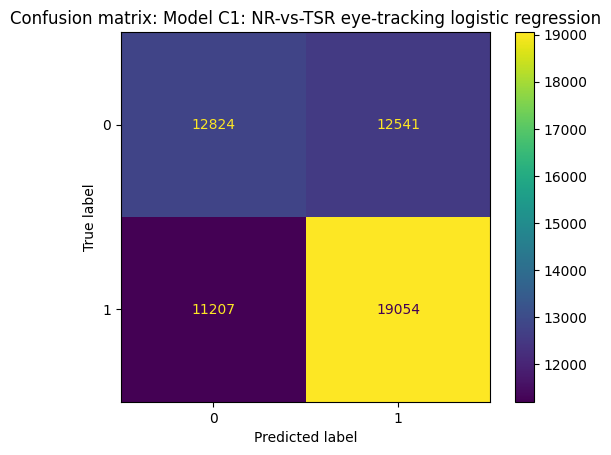

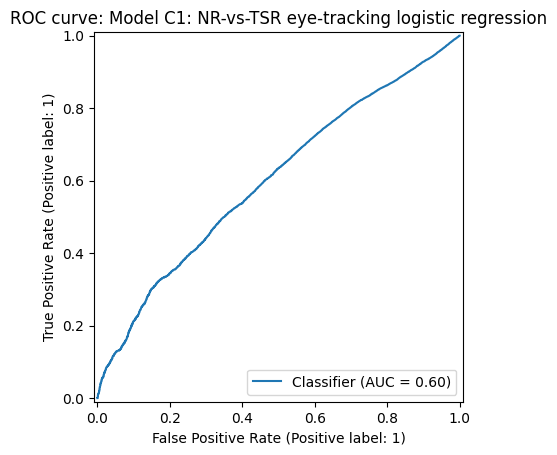

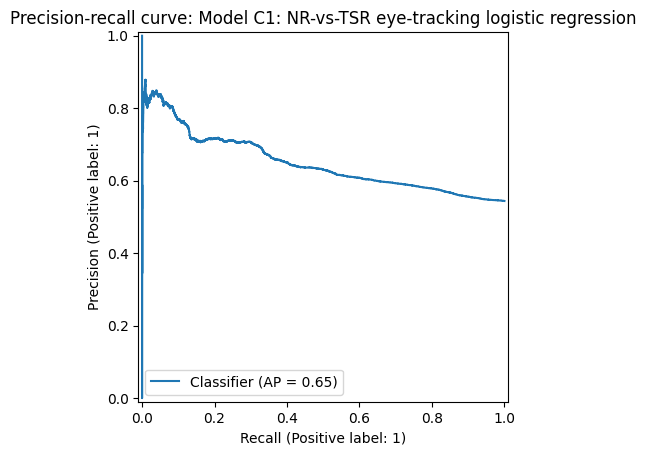

Grouped split for target_task_TSR: seed=42, train positive rate=0.544, test positive rate=0.544, absolute difference=0.000

=== Model C2: NR-vs-TSR eye-tracking random forest ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.614569,0.611375,0.645192,0.647665,0.646426,0.658026,0.702575,0.229914,Model C2: NR-vs-TSR eye-tracking random forest,target_task_TSR,rf,sentence_hash,174776,55626,497,166,0.543993,0.544008,0.475,0.625744,33340,"{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanc...",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.58      0.58      0.58     25365
           1       0.65      0.65      0.65     30261

    accuracy                           0.61     55626
   macro avg       0.61      0.61      0.61     55626
weighted avg       0.61      0.61      0.61     55626



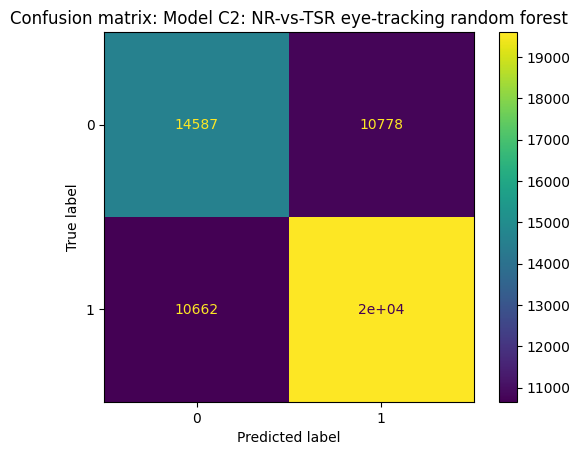

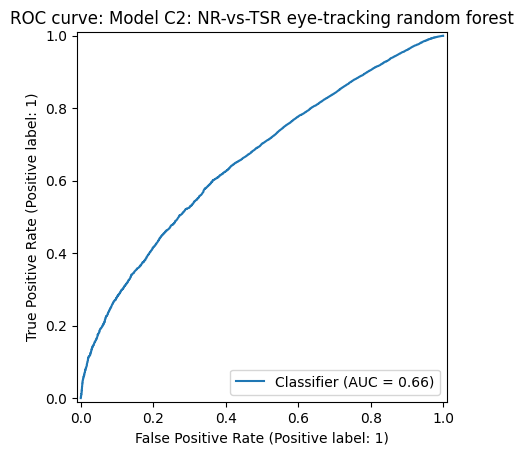

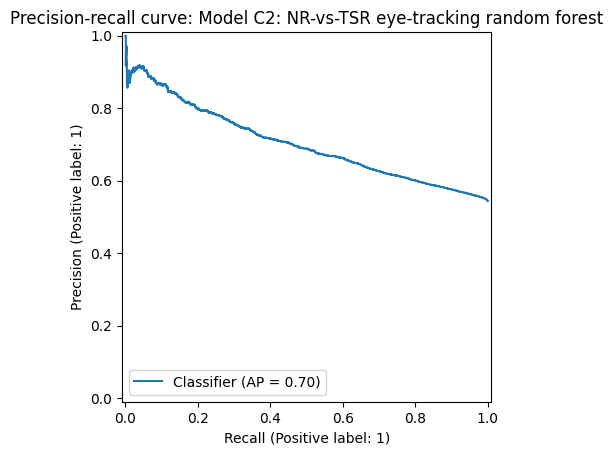

In [ ]:
if df_model["target_task_TSR"].notna().sum() == 0:
    print("Model C skipped: both NR and TSR are required.")
else:
    task_df = df_model[df_model["target_task_TSR"].notna()].copy()
    task_df["target_task_TSR"] = task_df["target_task_TSR"].astype(int)

    print("Task target distribution:")
    display(task_df["target_task_TSR"].value_counts(normalize=True).rename("proportion"))

    task_dummy_model, task_dummy_metrics, task_dummy_pred = fit_and_evaluate_model(
        df=task_df,
        target_col="target_task_TSR",
        numeric_features=TASK_CLASSIFICATION_NUMERIC,
        categorical_features=TASK_CLASSIFICATION_CATEGORICAL,
        model_type="dummy",
        model_name="Model C0: NR-vs-TSR dummy baseline",
        show_plots=False
    )

    task_logreg_model, task_logreg_metrics, task_logreg_pred = fit_and_evaluate_model(
        df=task_df,
        target_col="target_task_TSR",
        numeric_features=TASK_CLASSIFICATION_NUMERIC,
        categorical_features=TASK_CLASSIFICATION_CATEGORICAL,
        model_type="logreg",
        model_name="Model C1: NR-vs-TSR eye-tracking logistic regression"
    )

    task_rf_model, task_rf_metrics, task_rf_pred = fit_and_evaluate_model(
        df=task_df,
        target_col="target_task_TSR",
        numeric_features=TASK_CLASSIFICATION_NUMERIC,
        categorical_features=TASK_CLASSIFICATION_CATEGORICAL,
        model_type="rf",
        model_name="Model C2: NR-vs-TSR eye-tracking random forest"
    )

# 20A. Optional sentence-level task classification

The word-level task classifier may overstate sample size because a sentence contributes many words. This optional model aggregates eye-tracking features to the sentence level.

Scientific purpose:

> If NR vs TSR can still be classified at the sentence level, the task effect is less dependent on pseudo-replicated word rows.

This runs only when both NR and TSR are available.

Sentence-level task dataset: (11324, 14)


,subject_id,task,sentence_uid,sentence_hash,target_task_TSR,n_words,mean_word_length,skipping_rate,mean_FFD,mean_GD,mean_TRT,mean_GPT,mean_late_time,total_fixations
0,YAC,NR,YAC_NR_sent0,16815107985952348702,0,25,5.120000,0.280000,142.444444,152.611111,161.888889,180.888889,9.277778,20.0
1,YAC,NR,YAC_NR_sent1,13836197475387474422,0,17,6.294118,0.117647,115.333333,134.466667,224.333333,251.466667,89.866667,33.0
2,YAC,NR,YAC_NR_sent10,2011610967830131609,0,41,5.292683,0.292683,99.517241,152.310345,197.965517,203.758621,45.655172,43.0
3,YAC,NR,YAC_NR_sent100,4695502132493031821,0,12,5.500000,0.333333,117.750000,126.750000,212.125000,212.125000,85.375000,13.0
4,YAC,NR,YAC_NR_sent101,1343193994954843072,0,12,5.916667,0.333333,179.750000,191.625000,200.875000,222.750000,9.250000,10.0


Grouped split for target_task_TSR: seed=42, train positive rate=0.523, test positive rate=0.528, absolute difference=0.004

=== Model C3: sentence-level NR-vs-TSR classifier ===
Statistical interpretation:
- Test metrics below are evaluated on held-out groups only.
- decision_threshold was selected on validation data, not test data.
- balanced_accuracy is prioritised because high-load labels are usually imbalanced.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,target,model_type,group_col,n_train,n_test,n_train_groups,n_test_groups,positive_rate_train,positive_rate_test,decision_threshold,validation_score,n_validation,selected_params,hyperparameter_tuned,threshold_tuned,threshold_optimization_metric
0,0.602022,0.615655,0.749652,0.368925,0.494495,0.668851,0.728701,0.225349,Model C3: sentence-level NR-vs-TSR classifier,target_task_TSR,logreg,sentence_hash,8555,2769,497,166,0.523437,0.527627,0.625,0.640757,1594,"{'classifier__C': 10.0, 'classifier__class_weight': None}",True,True,balanced_accuracy



Classification report:
              precision    recall  f1-score   support

           0       0.55      0.86      0.67      1308
           1       0.75      0.37      0.49      1461

    accuracy                           0.60      2769
   macro avg       0.65      0.62      0.58      2769
weighted avg       0.66      0.60      0.58      2769



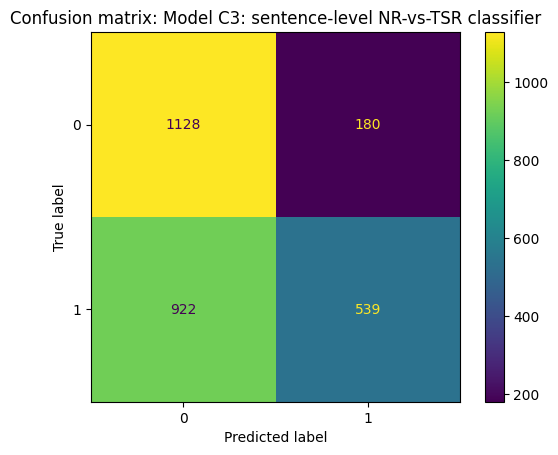

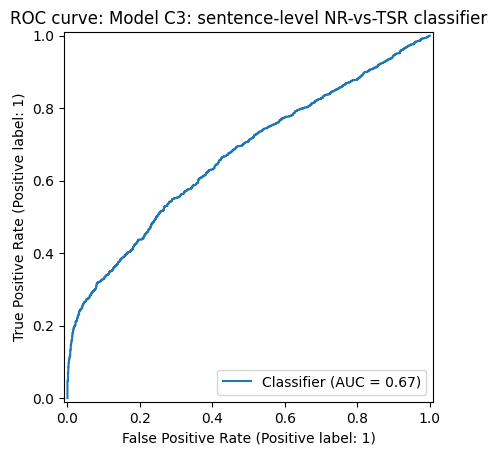

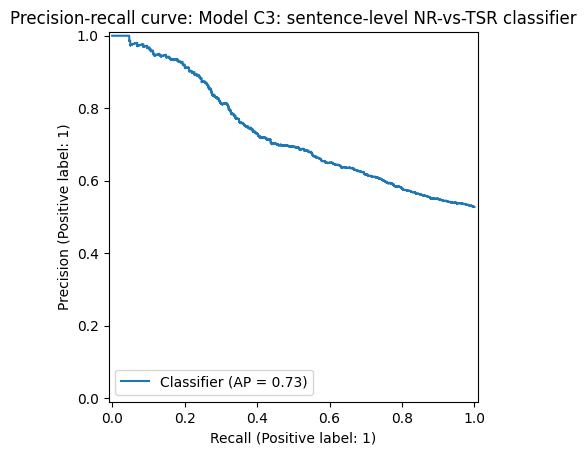

In [ ]:
if df_model["target_task_TSR"].notna().sum() == 0:
    print("Sentence-level task model skipped: both NR and TSR are required.")
else:
    sentence_task_df = (
        df_model
        .groupby(["subject_id", "task", "sentence_uid", "sentence_hash"], dropna=False)
        .agg(
            target_task_TSR=("target_task_TSR", "first"),
            n_words=("word", "count"),
            mean_word_length=("word_length", "mean"),
            skipping_rate=("skipped", "mean"),
            mean_FFD=("FFD", "mean"),
            mean_GD=("GD", "mean"),
            mean_TRT=("TRT", "mean"),
            mean_GPT=("GPT", "mean"),
            mean_late_time=("late_time", "mean"),
            total_fixations=("nFixations", "sum")
        )
        .reset_index()
    )

    sentence_features = [
        "n_words", "mean_word_length", "skipping_rate", "mean_FFD", "mean_GD",
        "mean_TRT", "mean_GPT", "mean_late_time", "total_fixations"
    ]

    print("Sentence-level task dataset:", sentence_task_df.shape)
    display(sentence_task_df.head())

    sent_task_model, sent_task_metrics, sent_task_pred = fit_and_evaluate_model(
        df=sentence_task_df,
        target_col="target_task_TSR",
        numeric_features=sentence_features,
        categorical_features=[],
        model_type="logreg",
        model_name="Model C3: sentence-level NR-vs-TSR classifier",
        group_col="sentence_hash",
        show_plots=True
    )

# 21. Optional subject-held-out validation

If you load multiple subjects, a stronger experiment is:

> Train on some readers, test on a held-out reader.

This tests generalisation across participants.

The cell runs only if at least two subjects are available.

In [ ]:
def subject_held_out_cv(
    df,
    target_col,
    numeric_features,
    categorical_features,
    model_type="logreg",
    subject_col="subject_id"
):
    data = df.dropna(subset=[target_col]).copy()
    subjects = sorted(data[subject_col].dropna().unique())

    if len(subjects) < 2:
        print("Subject-held-out CV skipped: need at least two subjects.")
        return None

    rows = []

    for held_out in subjects:
        train_df = data[data[subject_col] != held_out].copy()
        test_df = data[data[subject_col] == held_out].copy()

        if train_df[target_col].nunique() < 2 or test_df[target_col].nunique() < 2:
            print(f"Skipping {held_out}: insufficient class variation.")
            continue

        features = numeric_features + categorical_features

        X_train = train_df[features]
        y_train = train_df[target_col].astype(int)

        X_test = test_df[features]
        y_test = test_df[target_col].astype(int)

        model = make_classifier_pipeline(
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            model_type=model_type
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_score = None
        if hasattr(model.named_steps["classifier"], "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]

        metrics = safe_binary_metrics(y_test, y_pred, y_score)
        metrics["held_out_subject"] = held_out
        metrics["n_train"] = len(train_df)
        metrics["n_test"] = len(test_df)

        rows.append(metrics)

    if not rows:
        return None

    return pd.DataFrame(rows)


subject_cv_results = subject_held_out_cv(
    df=late_df,
    target_col="target_high_late_load",
    numeric_features=EARLY_EYE_NUMERIC,
    categorical_features=LEXICAL_CATEGORICAL,
    model_type="logreg"
)

if subject_cv_results is not None:
    display(subject_cv_results)
    subject_cv_path = OUTPUT_DIR / "subject_held_out_cv_results.csv"
    subject_cv_results.to_csv(subject_cv_path, index=False)
    print("Saved:", subject_cv_path)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,held_out_subject,n_train,n_test
0,0.554229,0.613297,0.180494,0.692922,0.286388,0.670047,0.244115,0.240815,YAC,130840,6786
1,0.611310,0.604861,0.341222,0.591931,0.432898,0.638788,0.352850,0.230974,YAG,126450,11176
2,0.569659,0.587173,0.097043,0.607595,0.167357,0.640712,0.134262,0.236776,YAK,128747,8879
3,0.576923,0.597632,0.279023,0.633484,0.387409,0.635759,0.317095,0.238620,YDG,129254,8372
4,0.538424,0.571620,0.277138,0.632812,0.385464,0.601258,0.299778,0.248976,YDR,131471,6155
5,0.585206,0.580219,0.317165,0.570235,0.407615,0.607147,0.331915,0.237734,YFR,129974,7652
6,0.525598,0.576836,0.246210,0.662387,0.358985,0.620253,0.297489,0.252072,YFS,131024,6602
7,0.550711,0.599755,0.194872,0.668867,0.301812,0.645693,0.232111,0.244070,YHS,131365,6261
8,0.528881,0.591624,0.238969,0.692032,0.355261,0.641512,0.302402,0.251358,YIS,130199,7427
9,0.588706,0.565160,0.263818,0.524259,0.351004,0.594319,0.270784,0.234705,YLS,130631,6995


Saved: /content/drive/MyDrive/ZuCo/outputs/subject_held_out_cv_results.csv


# 22. Save outputs

The notebook saves:

1. cleaned word-level eye-tracking table  
2. ML-ready table with targets  
3. B-series prediction tables  
4. B-series model comparison outputs  
5. reproducibility manifest  

The saved outputs are aligned around the same central question:

> **Do FFD-based early fixation signals robustly improve prediction of high late processing load?**

In [ ]:
import json

cleaned_path = OUTPUT_DIR / "zuco_cleaned_eye_tracking_word_level.csv"
model_path = OUTPUT_DIR / "zuco_ml_ready_eye_tracking_word_level.csv"
manifest_path = OUTPUT_DIR / "reproducibility_manifest.json"

df.to_csv(cleaned_path, index=False)
df_model.to_csv(model_path, index=False)

print("Saved cleaned data:", cleaned_path)
print("Saved ML-ready data:", model_path)

B_PREDICTION_OUTPUTS = {
    "B1_lexical_baseline": late_lex_pred,
    "B2_additive_FFD": late_early_pred,
    "B3_moderated_FFD": late_firstpass_pred,
    "B4_nonlinear_FFD": late_rf_pred,
}

for name, pred_df in B_PREDICTION_OUTPUTS.items():
    if pred_df is not None:
        out_path = OUTPUT_DIR / f"model_{name}_high_late_load_predictions.csv"
        pred_df.to_csv(out_path, index=False)
        print("Saved:", out_path)

if "error_df" in globals() and isinstance(error_df, pd.DataFrame) and not error_df.empty:
    error_path = OUTPUT_DIR / "model_B_series_error_analysis.csv"
    error_df.to_csv(error_path, index=False)
    print("Saved B-series error analysis:", error_path)

if "sent_task_pred" in globals() and sent_task_pred is not None:
    sent_task_path = OUTPUT_DIR / "sentence_level_task_predictions.csv"
    sent_task_pred.to_csv(sent_task_path, index=False)
    print("Saved sentence-level task predictions:", sent_task_path)

# Save extraction log when available.
if "log_df" in globals() and isinstance(log_df, pd.DataFrame) and not log_df.empty:
    log_path = OUTPUT_DIR / "zuco_extraction_log.csv"
    log_df.to_csv(log_path, index=False)
    print("Saved extraction log:", log_path)

manifest = {
    "DATA_DIR": str(DATA_DIR),
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "OSF_ROOT_NODE_ID": OSF_ROOT_NODE_ID,
    "SUBJECTS": SUBJECTS,
    "TASKS": TASKS,
    "AUTO_DISCOVER_ALL_LOCAL_MAT_FILES": AUTO_DISCOVER_ALL_LOCAL_MAT_FILES,
    "USE_OSF_DISCOVERY": USE_OSF_DISCOVERY,
    "DOWNLOAD_FROM_OSF": DOWNLOAD_FROM_OSF,
    "GROUP_COL_FOR_VALIDATION": GROUP_COL_FOR_VALIDATION,
    "USE_TASK_AS_FEATURE": USE_TASK_AS_FEATURE,
    "RANDOM_STATE": RANDOM_STATE,
    "TUNE_MODEL_HYPERPARAMETERS": TUNE_MODEL_HYPERPARAMETERS,
    "TUNE_CLASSIFICATION_THRESHOLD": TUNE_CLASSIFICATION_THRESHOLD,
    "THRESHOLD_OPTIMIZATION_METRIC": THRESHOLD_OPTIMIZATION_METRIC,
    "VALIDATION_SIZE": VALIDATION_SIZE,
    "TUNING_MAX_CANDIDATES": TUNING_MAX_CANDIDATES,
    "n_rows_cleaned": int(len(df)),
    "n_rows_model": int(len(df_model)),
    "n_subjects": int(df_model["subject_id"].nunique()),
    "n_tasks": int(df_model["task"].nunique()),
    "n_source_files": int(df_model["source_file"].nunique()),
    "central_research_question": "Do FFD-based early fixation signals robustly improve prediction of high late processing load beyond lexical/contextual features?",
    "target": "target_high_late_load based on late_time = TRT - GD",
    "lexical_numeric_features_B1": LEXICAL_NUMERIC,
    "lexical_categorical_features": LEXICAL_CATEGORICAL,
    "additive_FFD_features_B2": EARLY_EYE_NUMERIC,
    "moderated_FFD_features_B3": CONFIRMATORY_FFD_INTERACTION_NUMERIC,
    "nonlinear_FFD_features_B4": CONFIRMATORY_FFD_NONLINEAR_NUMERIC,
    "forbidden_features_for_high_late_load": sorted(FORBIDDEN_FEATURES_BY_TARGET["target_high_late_load"]),
}

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved reproducibility manifest:", manifest_path)

Saved cleaned data: /content/drive/MyDrive/ZuCo/outputs/zuco_cleaned_eye_tracking_word_level.csv
Saved ML-ready data: /content/drive/MyDrive/ZuCo/outputs/zuco_ml_ready_eye_tracking_word_level.csv
Saved: /content/drive/MyDrive/ZuCo/outputs/model_B1_lexical_baseline_high_late_load_predictions.csv
Saved: /content/drive/MyDrive/ZuCo/outputs/model_B2_additive_FFD_high_late_load_predictions.csv
Saved: /content/drive/MyDrive/ZuCo/outputs/model_B3_moderated_FFD_high_late_load_predictions.csv
Saved: /content/drive/MyDrive/ZuCo/outputs/model_B4_nonlinear_FFD_high_late_load_predictions.csv
Saved B-series error analysis: /content/drive/MyDrive/ZuCo/outputs/model_B_series_error_analysis.csv
Saved sentence-level task predictions: /content/drive/MyDrive/ZuCo/outputs/sentence_level_task_predictions.csv
Saved extraction log: /content/drive/MyDrive/ZuCo/outputs/zuco_extraction_log.csv
Saved reproducibility manifest: /content/drive/MyDrive/ZuCo/outputs/reproducibility_manifest.json


# 23. How to write the results statistically and scientifically

Use this template after running the notebook.

## Methods

> Word-level eye-tracking variables were extracted from ZuCo 2.0 MATLAB files. The analysis unit was a word read by a participant in a sentence. Skipped words were treated as a behavioural outcome, while duration-based analyses were restricted to fixated words. Late processing load was operationalised as `late_time = TRT - GD`, and high-load words were defined using rank-based top-quartile thresholds within subject-task groups.

## Model design

> A B-series model ladder was used to test whether FFD-based early fixation information improves prediction of high late processing load beyond lexical/contextual features. B1 used lexical/contextual predictors only. B2 added FFD and log-transformed FFD. B3 added FFD-by-context interaction terms. B4 used a nonlinear random forest with lexical/contextual features and FFD-based predictors. All B-series models used the same target and excluded outcome-proximal predictors such as `GD`, `SFD`, `TRT`, `GPT`, `nFixations`, and `late_time`.

## Accuracy optimisation

> Hyperparameters and probability thresholds were selected on an internal validation split. Final metrics were computed on held-out groups that were not used for model fitting, threshold selection, or hyperparameter tuning.

## Main evidence statement

Fill in the numbers:

> The lexical baseline, B1, achieved balanced accuracy = ____. The additive FFD model, B2, achieved balanced accuracy = ____. The moderated FFD model, B3, achieved balanced accuracy = ____. The nonlinear FFD model, B4, achieved balanced accuracy = ____. Relative to B1, the FFD-based models [did / did not] show consistent improvement.

## Straight statistical interpretation

- Higher `balanced_accuracy` means better performance after accounting for class imbalance.
- Higher `F1` means better positive-class detection under the selected threshold.
- Higher `ROC-AUC` means better probability ranking independent of threshold.
- Higher `average_precision` means better precision-recall performance for the high-load class.
- Lower `Brier score` means better calibrated predicted probabilities.

## Interpretation if B2/B3/B4 improve over B1

> The result supports the hypothesis that early fixation behaviour contains robust predictive information about later word-level processing difficulty beyond lexical/contextual features.

## Interpretation if only B4 improves

> The result suggests that the FFD signal may be nonlinear or interaction-dependent, but the evidence should be interpreted cautiously because the simpler additive model did not show the same improvement.

## Interpretation if none improve over B1

> The result suggests that FFD alone may not provide substantial additional information about later processing load in this sample, or that more participants/tasks are needed to estimate the effect reliably.

## Limitation

> If only one subject is used, the results should be interpreted as a pilot demonstration rather than population-level evidence. A full study should include all available participants and evaluate subject-held-out generalisation.

# 24. Final research contribution

A strong final framing is:

> **This project develops a leakage-aware machine-learning framework for predicting late word-level processing load from early eye-tracking signals during natural and task-specific reading.**

The methodological contribution is the target design:

```text
early observable signal → later processing burden
```

rather than the less informative pattern:

```text
reading-time variable → same reading-time variable
```

## Recommended next expansion

After running this notebook for `YAC`, expand to:

```text
all ZuCo 2.0 participants
NR + TSR
subject-held-out validation
task-specific comparison
```

Then the stronger research question becomes:

> **Do early eye-tracking signals predict late processing load in a way that generalises across readers and reading tasks?**

# 25. Critical assessment checklist before reporting results

Before writing the final report, check the following:

## 1. Is this a pilot or a group-level study?

- 1 participant: pilot only
- 2–3 participants: case-series evidence
- many participants: stronger statistical/ML study

## 2. Do B2/B3/B4 improve over B1?

The key scientific pattern is:

```text
B1 lexical/contextual baseline
vs
B2 additive FFD
vs
B3 moderated FFD
vs
B4 nonlinear FFD
```

Report B3 and B4 as robustness checks for the same FFD-based prediction question.

## 3. Was accuracy improved validly?

Check that:

```text
hyperparameters selected on validation data
threshold selected on validation data
test metrics computed only after tuning
```

Do not choose thresholds from the test-set diagnostic plot.

## 4. Did the validation split avoid leakage?

Prefer:

```text
GROUP_COL_FOR_VALIDATION = "sentence_hash"
```

because it prevents the same sentence text from appearing in both train and test.

## 5. Are B-series models using aligned predictors?

For `target_high_late_load`, the B-series should not use:

```text
GD, SFD, TRT, GPT, nFixations, late_time
```

B3/B4 should remain FFD-centred robustness models.

## 6. Are skipped words treated correctly?

Skipped words should be analysed as a behavioural outcome.  
Do not impute skipped-word reading times and then interpret them as real fixation durations.

## 7. Are the targets balanced enough?

If `target_high_late_load` has too few positives or negatives, model performance is unstable.  
Use the target-distribution tables before interpreting metrics.

## 8. Are results generalisable?

For scientific claims, add more participants and run subject-held-out validation.

# 26. v3 critical-methods appendix: what to check after running

Use this as a final audit before writing your results.

## A. Extraction integrity

Check:

```text
SFD availability by file
extraction log size
negative duration flags
fixated words with missing duration values
```

If many fixated words have missing `FFD`, `GD`, or `TRT`, do not proceed directly to modelling.

## B. Target validity

Check:

```text
target_high_late_load distribution
target counts by subject-task
late_time distribution
```

If the positive class is extremely rare or all values are tied, the target is not stable.

## C. Leakage control

Confirm that `target_high_late_load` models do **not** use:

```text
GD, SFD, TRT, GPT, nFixations, late_time
```

The notebook's leakage guard should enforce this.

## D. Unified evidence hierarchy

Prioritise the full aligned B-series:

```text
B1 lexical/contextual baseline
B2 additive FFD
B3 moderated FFD
B4 nonlinear FFD
```

A robust conclusion is strongest when B2, B3, and/or B4 consistently improve over B1.

## E. Generalisation level

Use these labels accurately:

```text
1 participant = pilot demonstration
2–3 participants = case-series evidence
many participants + subject-held-out validation = stronger generalisation test
```

## F. Recommended final claim structure

A careful result statement should look like:

> In a sentence-grouped validation setting, FFD-based models [improved / did not improve] prediction of high late processing load compared with a lexical/contextual baseline. This suggests that early fixation behaviour [does / does not] provide robust additional predictive information about later word-level processing burden in this sample.